In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline                        
#导入 Matplotlib 库，用于绘图和可视化
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager
# 解决 Matplotlib 中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用户
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

In [6]:
# 读取数据
data = pd.read_csv("C:/Users/Miss.Chen/Desktop/论文/数据集/heart.csv")
#显示 data 变量的类型
type(data)

pandas.core.frame.DataFrame

In [7]:
data.shape

(303, 14)

In [8]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.712871,2.320132,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,0.976580,0.592299,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


data.describe() 适用于 Pandas 的 DataFrame 或 Series，它会计算数值列（或指定列）的基本统计信息，包括：

count：非空值的数量
mean：均值（平均值）
std：标准差
min：最小值
25%：第 25 百分位数（第一四分位数）
50%：第 50 百分位数（中位数）
75%：第 75 百分位数（第三四分位数）
max：最大值


1. 百分位数（Percentile）
百分位数表示数据排序后，在某个百分比位置的数值。例如，第 25 百分位数（25th percentile）表示数据中有 25% 的值小于等于它。

25%（第一四分位数，Q1）

数据从小到大排列后，处于 前 25% 位置的数。
也称 Q1（第一四分位数），表示数据中 有 25% 的值比它小，75% 的值比它大。
它反映的是 数据分布的下四分之一部分的边界。
50%（第二四分位数，中位数，Q2）

数据的 中位数（Median），即 一半数据比它小，一半数据比它大。
也称 Q2（第二四分位数），表示数据在中间的位置。
它反映的是 数据的中点，适用于衡量数据的集中趋势，特别是当数据有极端值时，中位数比平均值更稳健。
75%（第三四分位数，Q3）

数据排序后，处于 前 75% 位置的数。
也称 Q3（第三四分位数），表示数据中 有 75% 的值比它小，25% 的值比它大。
它反映的是 数据分布的上四分之一部分的边界。

3. 四分位数的作用
四分位数用于衡量数据的 离散程度 和 分布情况：

数据是否对称：如果 Q2 接近 Q1 和 Q3 的中点，则数据较对称。
数据是否偏斜：如果 Q2 更接近 Q1 或 Q3，说明数据可能偏斜。
判断异常值：通常，Q1 - 1.5*IQR 和 Q3 + 1.5*IQR 之外的点被视为异常值，其中 IQR = Q3 - Q1。

这些统计量可以帮助我们快速了解数据的分布，判断是否有异常值，以及数据的对称性和偏斜程度。


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


data.info() 的作用是提供数据集的基本信息，包括以下内容：

数据集的结构：

显示数据的行数（样本数量）和列数（特征数量）。
每列的数据类型：

识别数据类型（如 int64、float64、object 等），有助于确认数据格式是否正确，避免数据类型错误影响模型训练。

缺失值情况：
Non-Null Count 列显示每个特征的非空（非 NaN）值数量，有助于检测缺失值，以便后续数据预处理（填充或删除）。

内存占用：
显示数据集占用的内存大小，有助于优化数据存储和处理效率。

In [11]:
data.sample(5)   

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
58,34,1,3,118,182,0,0,174,0,0.0,2,0,2,1
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
262,53,1,0,123,282,0,1,95,1,2.0,1,2,3,0
110,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1


In [12]:
#统计数据集中每一列缺失值的数量
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
#统计数据集中所有缺失值的总数量
data.isnull().sum().sum()

0

数据集没有缺失值，清洗结束

In [14]:
#计算数据集各个特征与 target 目标变量之间的相关性，按照相关性大小，从高到低排列.
'''
data.corr()：计算 data 数据集中所有特征之间的相关性矩阵，包括它们与 target 变量的相关性。默认使用皮尔逊相关系数（Pearson correlation coefficient）。
["target"]：从相关性矩阵中提取 target 这一列的数据，即所有特征与 target 变量的相关性。
.abs()：取相关性值的绝对值，这样可以忽略正负方向，仅关注相关性大小。
.sort_values(ascending=False)：按照相关性的绝对值大小降序排序，使最相关的特征排在最前面。
'''
print(data.corr()["target"].abs().sort_values(ascending=False))


target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.418868
thal        0.356631
slope       0.345877
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


In [15]:
#运行结果表明大多数列与目标中等相关，但“fbs”相关性非常弱。

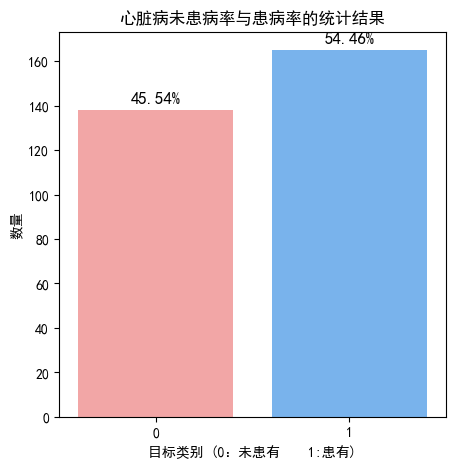

target
1    165
0    138
Name: count, dtype: int64


In [16]:
#探索性数据分析 (EDA) 分析 target 变量的分布情况
import matplotlib.pyplot as plt
import seaborn as sns

# 统计目标变量 target 的类别数量
y = data["target"]

# 计算总样本数（定义 total）
total = len(y)  

# 画柱状图，并指定颜色，帮助识别类别是否均衡
plt.figure(figsize=(5, 5))  
ax = sns.countplot(x=y, hue=y, palette=["#FF9999", "#66B3FF"], legend=False)

# 设置中文标签
plt.xlabel("目标类别 (0：未患有    1:患有)")
plt.ylabel("数量")
plt.title("心脏病未患病率与患病率的统计结果")

# 显示百分比
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            '{:.2f}%'.format((height / total) * 100),  # 正确调用 total
            ha="center", 
            fontsize=12)
# 保存图表（可选择不同格式，如 PNG、JPG、PDF）
plt.savefig("heart_disease_distribution.png", dpi=150, bbox_inches='tight', pad_inches=0.05) # 保存为高分辨率 PNG
plt.show()


# 输出各类别的数量
target_temp = data.target.value_counts()
print(target_temp)

'''
target 只有两个值（0 和 1），所以是一个二分类任务
结果显示：
患有或不患有心脏病的患者百分比：
1 类占比约 54.46%，0 类占比约 45.54%，
在总共 303 名患者的数据中，有 165 名患有心脏病，有 138名未患有心脏病。
说明数据分布相对均衡，1 稍微多一点。
因此，不需要额外处理类别不平衡问题。适合使用常规的分类算法进行建模。
'''

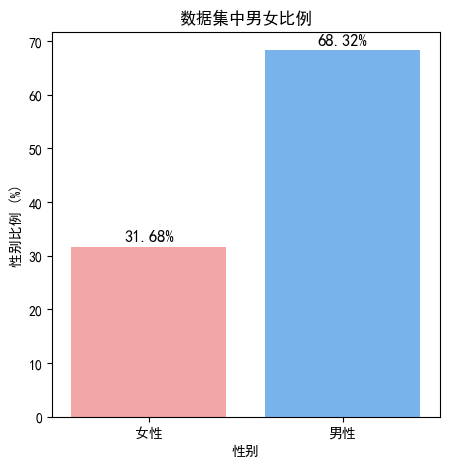

数据集中总人数：303
女性人数：96，占比 31.68%
男性人数：207，占比 68.32%


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统计数据集中所有人的性别比例
sex_counts = data["sex"].value_counts()
num_females = sex_counts.get(0, 0)  # 女性数量 (sex=0)
num_males = sex_counts.get(1, 0)    # 男性数量 (sex=1)

# 计算总人数
total_population = num_females + num_males  

# 计算性别百分比
female_percentage = num_females / total_population * 100
male_percentage = num_males / total_population * 100

# 重新组织数据，符合 Seaborn 规范
df = pd.DataFrame({
    "性别": ["女性", "男性"],
    "性别比例 (%)": [female_percentage, male_percentage]
})

# 绘制柱状图
plt.figure(figsize=(5, 5))  
ax = sns.barplot(data=df, x="性别", y="性别比例 (%)", hue="性别", palette={"女性": "#FF9999", "男性": "#66B3FF"}, legend=False)

# 显示百分比标签
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 1,  # 位置微调
            '{:.2f}%'.format(height),  # 显示百分比
            ha="center", 
            fontsize=12)

# 设置标题
plt.title("数据集中男女比例")

# 保存图表
plt.savefig("数据集的男女比例.png", dpi=150, bbox_inches='tight', pad_inches=0.05)

# 显示图表
plt.show()

# 输出男女总人数
print(f"数据集中总人数：{total_population}")
print(f"女性人数：{num_females}，占比 {female_percentage:.2f}%")
print(f"男性人数：{num_males}，占比 {male_percentage:.2f}%")


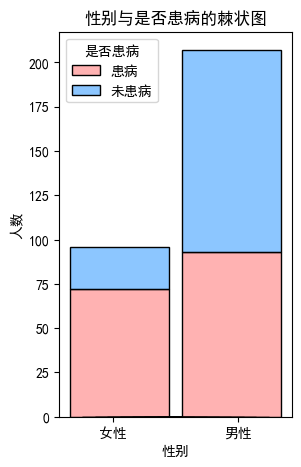

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置画布大小
plt.figure(figsize=(3, 5))

# 绘制棘状图（堆叠柱状图）
ax = sns.histplot(
    data=data, 
    x="sex", 
    hue="target", 
    multiple="stack",  # 使用堆叠模式
    palette={0: "#66B3FF", 1: "#FF9999"},  # 0（未患病）蓝色，1（患病）红色
    shrink=8 # 调整柱子宽度
)

# 设置标签
plt.xticks(ticks=[0, 1], labels=["女性", "男性"])  # 将 0,1 映射为 "女性" 和 "男性"
plt.xlabel("性别")
plt.ylabel("人数")
plt.title("性别与是否患病的棘状图")

# 显示图例
plt.legend(title="是否患病", labels=["患病", "未患病"])

# 保存图片
plt.savefig("sex_vs_disease_stacked.png", dpi=150, bbox_inches='tight', pad_inches=0.05)

# 显示图表
plt.show()


In [19]:
print(data["sex"].value_counts())      # 确保 0=女性, 1=男性
print(data["target"].value_counts())   # 确保 0=未患病, 1=患病
print(data.groupby(["sex", "target"]).size())  # 交叉统计性别和患病情况


sex
1    207
0     96
Name: count, dtype: int64
target
1    165
0    138
Name: count, dtype: int64
sex  target
0    0          24
     1          72
1    0         114
     1          93
dtype: int64


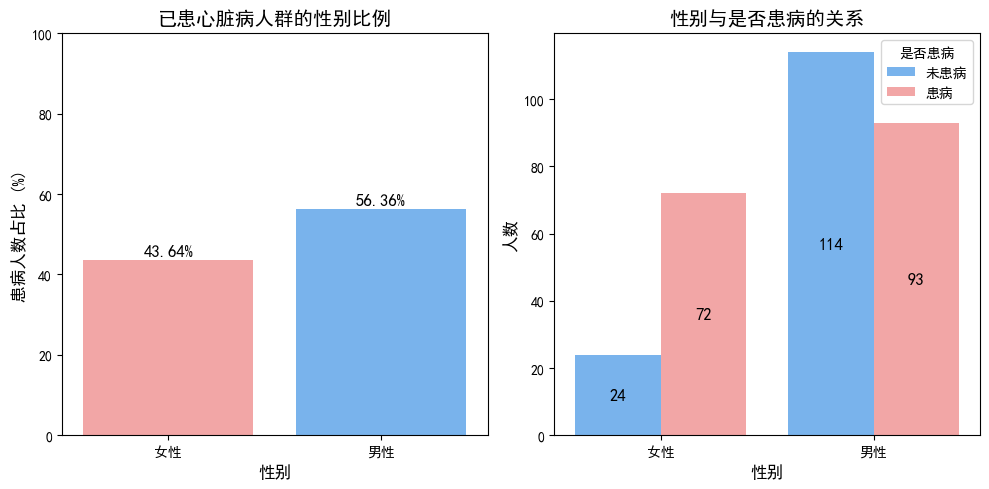

总患病人数: 165
女性患病人数: 72 (43.64%)
男性患病人数: 93 (56.36%)


In [20]:


# 统计所有患有心脏病的人数 (target=1)
heart_disease_data = data[data["target"] == 1]
total_patients_with_disease = len(heart_disease_data)

# 统计患病人群中不同性别的数量
sex_counts = heart_disease_data["sex"].value_counts()
num_females_with_disease = sex_counts.get(0, 0)  # 女性数量 (sex=0)
num_males_with_disease = sex_counts.get(1, 0)    # 男性数量 (sex=1)

# 计算患病百分比
female_percentage = num_females_with_disease / total_patients_with_disease * 100
male_percentage = num_males_with_disease / total_patients_with_disease * 100

# 创建数据框（性别患病比例）
df_ratio = pd.DataFrame({
    "性别": ["女性", "男性"],
    "患病比例 (%)": [female_percentage, male_percentage]
})

# 统计数据集中所有人的性别和患病情况
sex_target_counts = data.groupby(["sex", "target"]).size().unstack().fillna(0)
num_females_healthy = sex_target_counts.loc[0, 0]  # 女性未患病人数
num_males_healthy = sex_target_counts.loc[1, 0]    # 男性未患病人数

# 创建数据框（性别与是否患病的堆叠柱状图）
df_stacked = pd.DataFrame({
    "性别": ["女性", "女性", "男性", "男性"],
    "是否患病": ["未患病", "患病", "未患病", "患病"],
    "人数": [num_females_healthy, num_females_with_disease, num_males_healthy, num_males_with_disease]
})

# 设置画布大小
plt.figure(figsize=(10, 5))

# 绘制第一个图：性别患病比例
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=df_ratio, x="性别", y="患病比例 (%)", hue="性别",
                  palette={"女性": "#FF9999", "男性": "#66B3FF"}, legend=False)

# 显示百分比标签
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width() / 2, height + 1, f"{height:.2f}%",
             ha="center", fontsize=12)

# 设置标题和标签
plt.xlabel("性别", fontsize=12)
plt.ylabel("患病人数占比 (%)", fontsize=12)
plt.title("已患心脏病人群的性别比例", fontsize=14)
plt.ylim(0, 100)

# 绘制第二个图：性别与是否患病的堆叠柱状图
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=df_stacked, x="性别", y="人数", hue="是否患病",
                  palette={"未患病": "#66B3FF", "患病": "#FF9999"})

# 显示数值标签
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.text(p.get_x() + p.get_width() / 2, height / 2, f"{int(height)}",
                 ha="center", va="center", fontsize=12, color="black", weight="bold")

# 设置标题和标签
plt.xlabel("性别", fontsize=12)
plt.ylabel("人数", fontsize=12)
plt.title("性别与是否患病的关系", fontsize=14)
plt.legend(title="是否患病")

# 调整布局，防止重叠
plt.tight_layout()

# 保存图像
plt.savefig("heart_disease_analysis.png", dpi=150, bbox_inches='tight', pad_inches=0.05)

# 显示图表
plt.show()

# 打印统计结果
print(f"总患病人数: {total_patients_with_disease}")
print(f"女性患病人数: {num_females_with_disease} ({female_percentage:.2f}%)")
print(f"男性患病人数: {num_males_with_disease} ({male_percentage:.2f}%)")


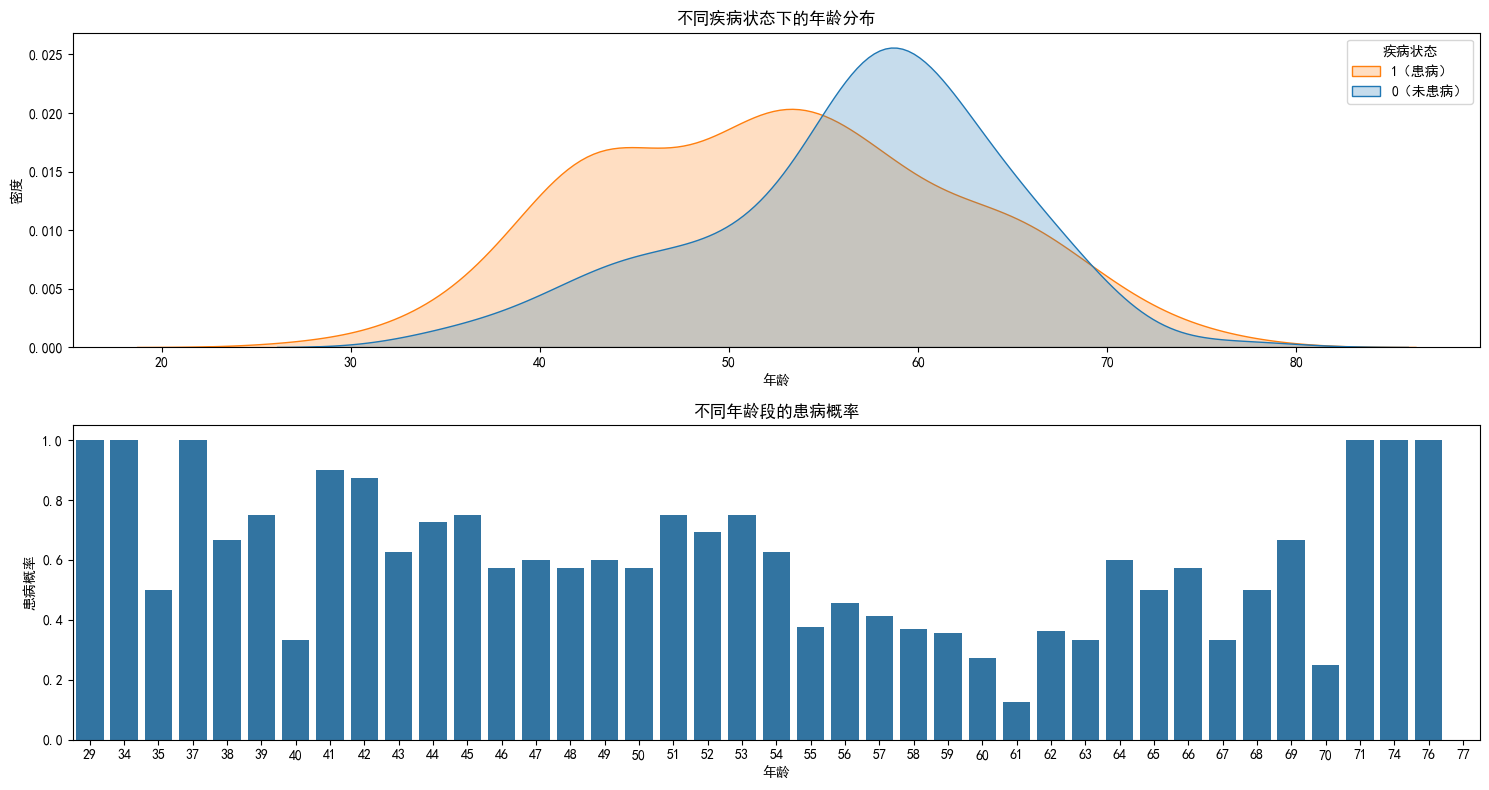

In [21]:
"""
绘制年龄与疾病状态的关系：
    上图：核密度估计（KDE）展示不同疾病状态下的年龄分布
    下图：条形图展示每个年龄的平均患病概率
"""


def plot_age(data):

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8))  # 创建 2 行 1 列的子图

    # 绘制 KDE 曲线，显示不同 target（疾病状态）下的年龄分布
    sns.kdeplot(data=data, x="age", hue="target", fill=True, ax=axes[0])
    
    # 手动设置图例，避免 IndexError
    axes[0].legend(["1（患病）","0（未患病）"], title="疾病状态")

    axes[0].set(xlabel="年龄", ylabel="密度", title="不同疾病状态下的年龄分布")

    # 按年龄分组，计算平均患病概率
    avg = data.groupby("age", as_index=False)["target"].mean()

    # 绘制条形图，展示年龄与患病概率的关系
    sns.barplot(x="age", y="target", data=avg, ax=axes[1])
    axes[1].set(xlabel="年龄", ylabel="患病概率", title="不同年龄段的患病概率")

    # 解决横轴刻度重叠问题：每隔 1年显示一个刻度
    axes[1].set_xticks(axes[1].get_xticks()[::1])  
     # **保存两张图表**
    fig.savefig("年龄与疾病状态_KDE_条形图.png", dpi=150, bbox_inches='tight', pad_inches=0.1)
    axes[0].get_figure().savefig("年龄_疾病状态_KDE.png", dpi=150, bbox_inches='tight', pad_inches=0.1)  # KDE 图
    axes[1].get_figure().savefig("年龄_患病概率_条形图.png", dpi=150, bbox_inches='tight', pad_inches=0.1)  # 条形图

    plt.tight_layout()  # 自动调整布局，防止重叠


    plt.show()  # 显示图表

# 调用函数（请确保 data 变量已定义，并包含 "age" 和 "target" 列）
plot_age(data)

'''
上图（年龄分布 KDE 曲线）：
   50-65 岁是患病高发期：患病（蓝色）和未患病（橙色）人群的年龄分布都集中在 50-65 岁，但患病人群在 50 岁左右达到峰值。  
    年轻人患病概率较低： 30 岁以下人群基本没有病例，说明年轻人患病的可能性较小。  
    年老群体（70+）患病趋势下降：70岁以上的患病分布逐渐减少，可能是因为数据集中老年人样本较少，或该群体生存率受疾病影响。

下图（年龄 vs. 平均患病概率）：
40-55 岁的患病概率较高：这一区间的患病概率普遍在 60% 以上，某些年龄（如 41、42、52、53 岁）甚至接近 100%。  
60 岁以上患病概率波动较大：患病概率出现较大波动，可能是由于样本量不足，导致某些年龄段的概率偏高或偏低。  
30 岁以下样本较少或无病例，符合 KDE 图的趋势。

可能的医学/健康解释：
1. 40-60 岁是心血管疾病高发期，尤其是 50 岁左右，可能是由于高血压、高血脂、糖尿病等慢性疾病的影响。  
2. 年轻人（30 岁以下）较少患病，可能是因为他们代谢较好，身体机能较强。  
3. 老年人（70 岁以上）数据减少 可能有两种原因：
   - 该年龄段的部分患者可能因疾病并发症去世，导致样本减少。
   - 70 岁以上的人口可能相对健康，或有更好的医疗管理。  

'''

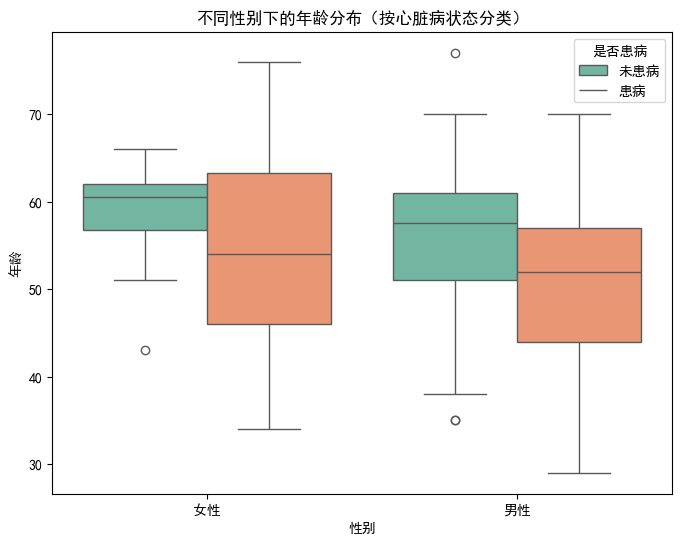

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x="sex", y="age", hue="target", palette="Set2")
plt.xticks(ticks=[0, 1], labels=["女性", "男性"])  # 0 代表女性，1 代表男性
plt.xlabel("性别")
plt.ylabel("年龄")
plt.title("不同性别下的年龄分布（按心脏病状态分类）")
plt.legend(title="是否患病", labels=["未患病", "患病"])
plt.show()

In [23]:
#定义了一个函数 plotGrid(isCategorial)，它根据 isCategorial 的值，调用不同的绘图函数来绘制 离散变量或连续变量的数据分布。
'''
1. 参数
isCategorial（布尔值）：
True -> 处理 离散变量（离散数据）
False -> 处理 连续变量（数值数据）


2. 逻辑
如果 isCategorial == True：
[plotCategorial(x[0], x[1], i) for i, x in enumerate(categorial)]

遍历 categorial 变量（之前定义的离散变量列表）。
对于每个离散变量 x：
x[0]：变量名（如 'sex'）。
x[1]：该变量的类别列表（如 ['female', 'male']）。
i：当前变量的索引。
调用 plotCategorial() 进行绘图。


如果 isCategorial == False：
[plotContinuous(x[0], x[1], i) for i, x in enumerate(continuous)]
这表示：

遍历 continuous 变量（存储连续变量的列表）。
对于每个连续变量 x：
x[0]：变量名（如 'age'）。
x[1]：变量的数值数据（通常是 data[x[0]]）。
i：索引。
调用 plotContinuous() 进行绘图。

该函数的作用是 自动选择 离散变量或连续变量进行绘图，避免手动调用不同的绘图函数。
'''
def plotGrid(isCategorial):
    if isCategorial:
        [plotCategorial(x[0], x[1], i) for i, x in enumerate(categorial)] 
    else:
        [plotContinuous(x[0], x[1], i) for i, x in enumerate(continuous)]


In [24]:
categorial = [
    ('sex', ['女性', '男性']),  # 性别（sex）：分为女性和男性
    
    ('cp', ['典型心绞痛', '非典型心绞痛', '非心绞痛', '无症状']),
    # 胸痛类型（cp）：分为4种
    # - 典型心绞痛（typical angina）
    # - 非典型心绞痛（atypical angina）
    # - 非心绞痛（non-anginal pain）
    # - 无症状（asymptomatic）

    ('fbs', ['空腹血糖 > 120mg/dl', '空腹血糖 < 120mg/dl']),
    # 空腹血糖（fbs）：是否大于 120mg/dl
    # - 空腹血糖 > 120mg/dl（高于 120mg）
    # - 空腹血糖 < 120mg/dl（低于 120mg）

    ('restecg', ['正常', 'ST-T 波异常', '左心室肥大']),
    # 静息心电图（restecg）：分为3种
    # - 正常（normal）
    # - ST-T 波异常（ST-T wave）
    # - 左心室肥大（left ventricular）

    ('exang', ['是', '否']),
    # 运动诱发心绞痛（exang）：是否存在
    # - 是（yes）
    # - 否（no）

    ('slope', ['上升型', '平坦型', '下降型']),
    # ST 段坡度（slope）：分为3种
    # - 上升型（upsloping）
    # - 平坦型（flat）
    # - 下降型（downsloping）

    ('thal', ['正常', '固定缺陷', '可逆缺陷'])
    # 地中海贫血（thal）：分为3种
    # - 正常（normal）
    # - 固定缺陷（fixed defect）
    # - 可逆缺陷（reversible defect）
]


In [27]:

def plotCategorial(attribute, labels, ax_index):
    # 绘制第一个图：该离散变量的频数分布（计数图）
    ax1 = sns.countplot(x=attribute, data=data, ax=axes[ax_index][0])
    for p in ax1.patches:  # 在柱子上显示数值
        ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

    # 绘制第二个图：目标变量（如疾病状态）按该离散变量的分布
    ax2 = sns.countplot(x='target', hue=attribute, data=data, ax=axes[ax_index][1])
    for p in ax2.patches:  # 在柱子上显示数值
        if p.get_height() > 0:  
            ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

    # 绘制第三个图：按该离散变量计算平均的目标变量值（条形图）
    avg = data[[attribute, 'target']].groupby([attribute], as_index=False).mean()
    ax3 = sns.barplot(x=attribute, y='target', hue=attribute, data=avg, ax=axes[ax_index][2])
    for p in ax3.patches:  # 在柱子上显示均值
        if not p.get_height() == 0:
            ax3.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

    # 自定义第二个图的图例
    for t, l in zip(axes[ax_index][1].get_legend().texts, labels):
        t.set_text(l)  # 将图例文本设置为 labels

    # 自定义第三个图的图例
    for t, l in zip(axes[ax_index][2].get_legend().texts, labels):
        t.set_text(l)  # 将图例文本设置为 labels


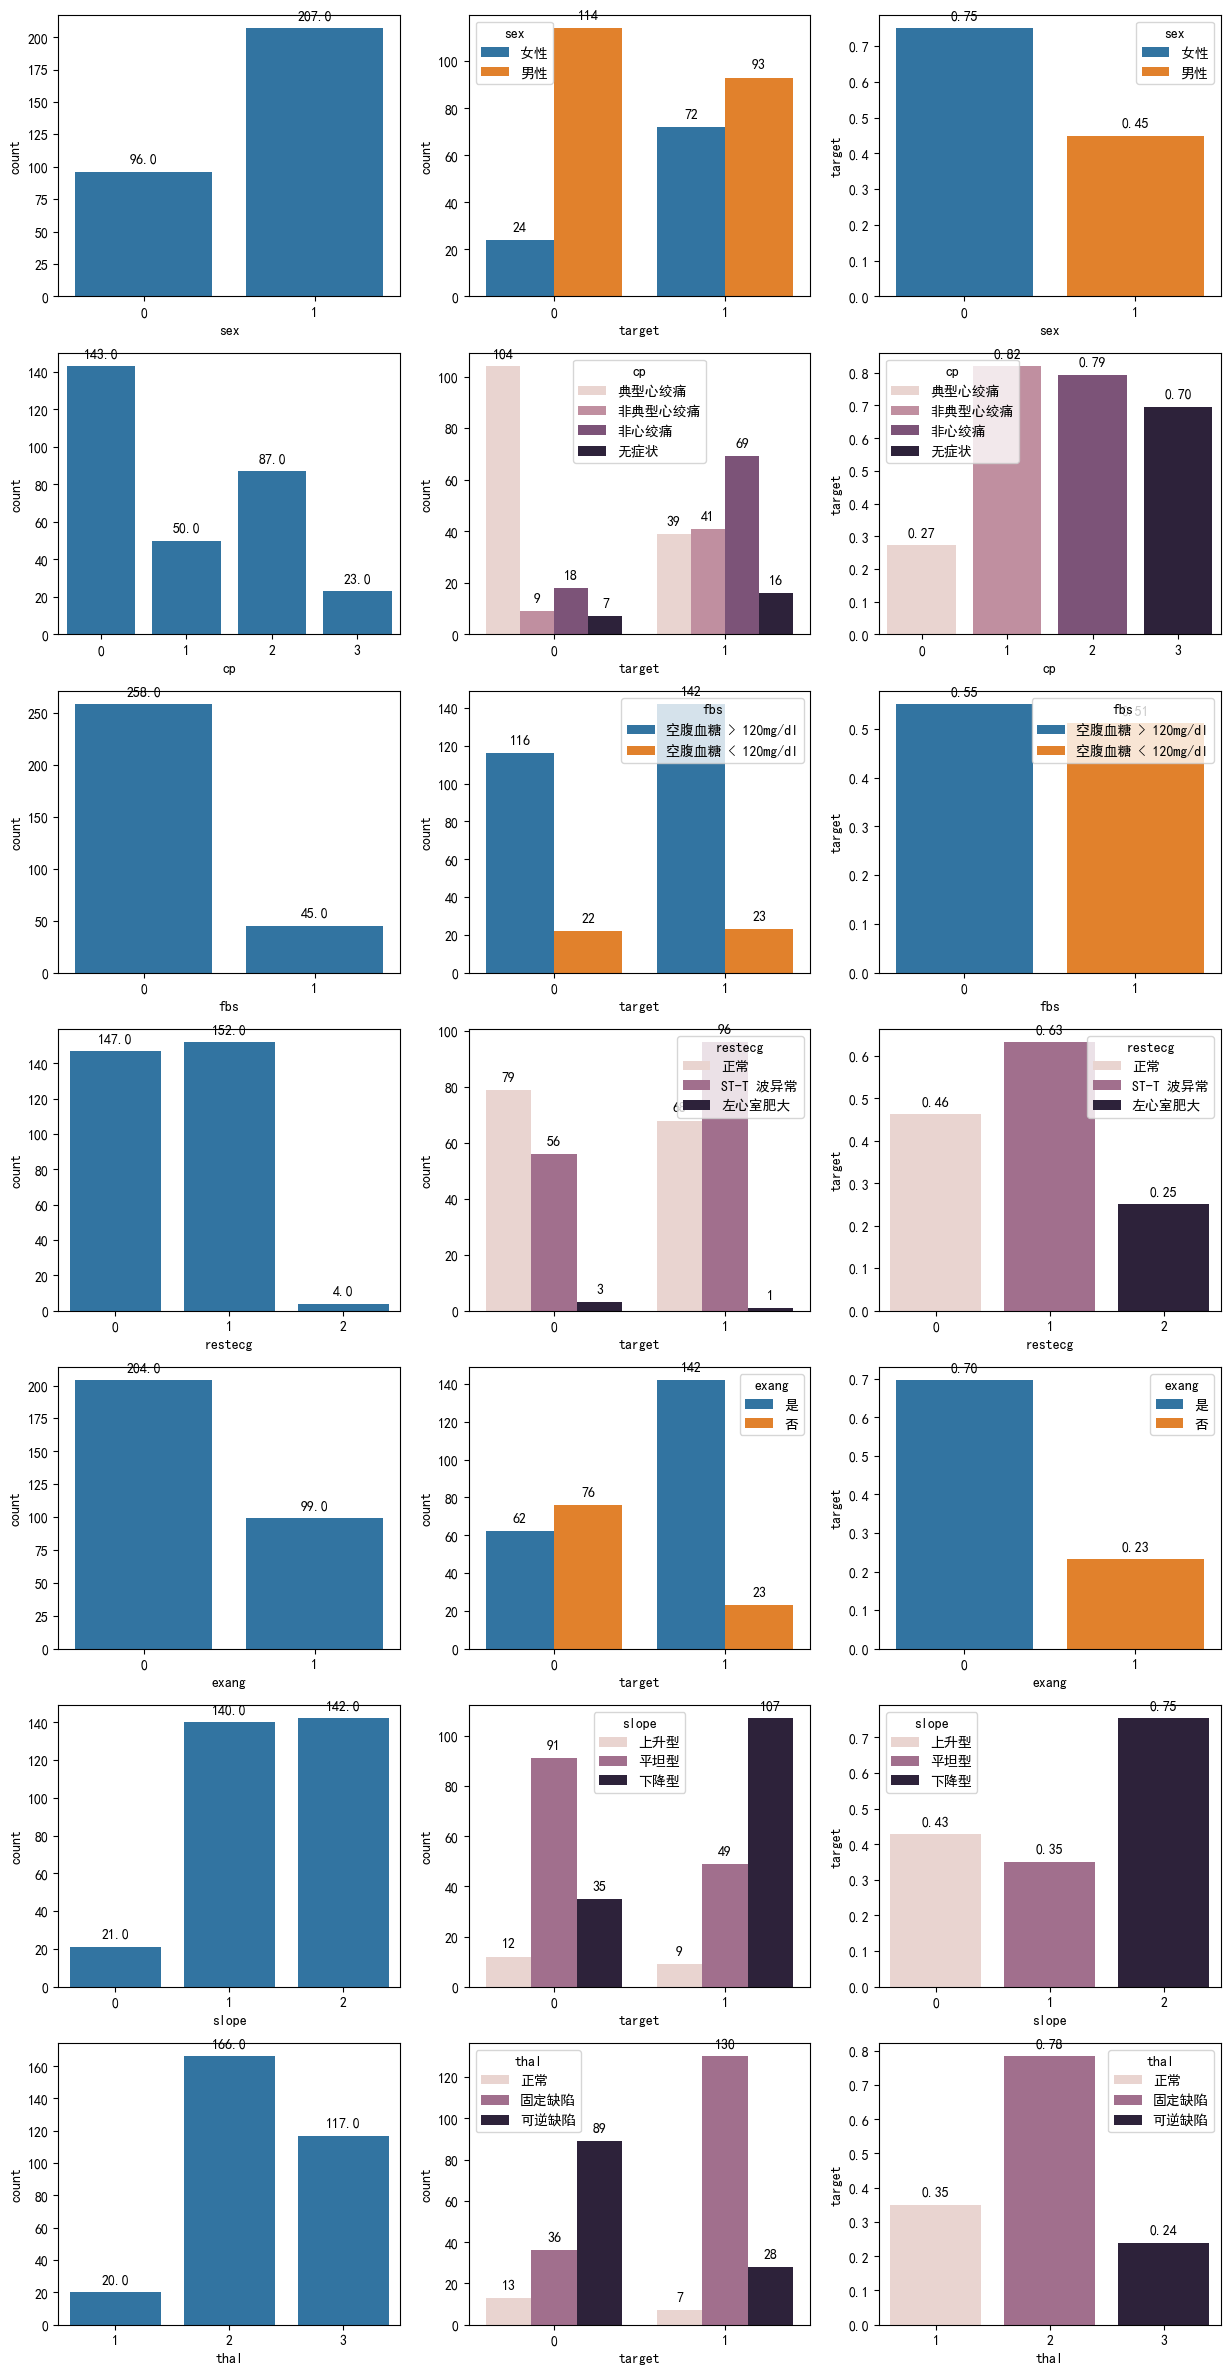

In [28]:

fig_categorial, axes = plt.subplots(nrows=len(categorial), ncols=3, figsize=(15, 30))

plotGrid(isCategorial=True)

In [29]:
#连续变量
continuous = [
    ('trestbps', '血压（mm Hg）'),  # 血压（mm Hg）
    ('chol', '血清胆固醇（mg/dl）'),  # 血清胆固醇（mg/dl）
    ('thalach', '最大心率'),  # 最大心率
    ('oldpeak', '运动相对静息的ST段抑制'),  # ST段抑制（运动相对静息）
    ('ca', '冠状动脉主血管数量（0-3，荧光透视显示）')  # 冠状动脉主血管数量（0-3，荧光透视显示）
]
# 将英语表述替换为中文
continuous = [
    ('trestbps', '血压（mm Hg）'),  # 血压（mm Hg）
    ('chol', '血清胆固醇（mg/dl）'),  # 血清胆固醇（mg/dl）
    ('thalach', '最大心率'),  # 最大心率
    ('oldpeak', '运动相对静息的ST段抑制'),  # ST段抑制（运动相对静息）
    ('ca', '冠状动脉主血管数量（0-3，荧光透视显示）')  # 冠状动脉主血管数量（0-3，荧光透视显示）
]

def plotContinuous(attribute, xlabel, ax_index):
    # 第一个图：绘制该连续变量的分布（直方图）
    ax1 = sns.histplot(data[[attribute]], ax=axes[ax_index][0], kde=True)  # 使用 histplot 代替 distplot
    for p in ax1.patches:  # 在直方图的每个柱子上显示数值
        ax1.annotate(f'{p.get_height():.2f}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', 
                     xytext=(0, 5), textcoords='offset points')
    
    ax1.set(xlabel=xlabel, ylabel='密度')  # 设置轴标签，使用中文

    # 第二个图：绘制该变量按目标变量（患病与否）的分布（小提琴图）
    ax2 = sns.violinplot(x='target', y=attribute, data=data, ax=axes[ax_index][1])
    for patch in ax2.patches:  # 在小提琴图的每个图形顶部显示数值
        ax2.annotate(f'{patch.get_height():.2f}', 
                     (patch.get_x() + patch.get_width() / 2., patch.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', 
                     xytext=(0, 5), textcoords='offset points')
    
    ax2.set(xlabel='是否患病', ylabel=xlabel)  # 设置轴标签，使用中文



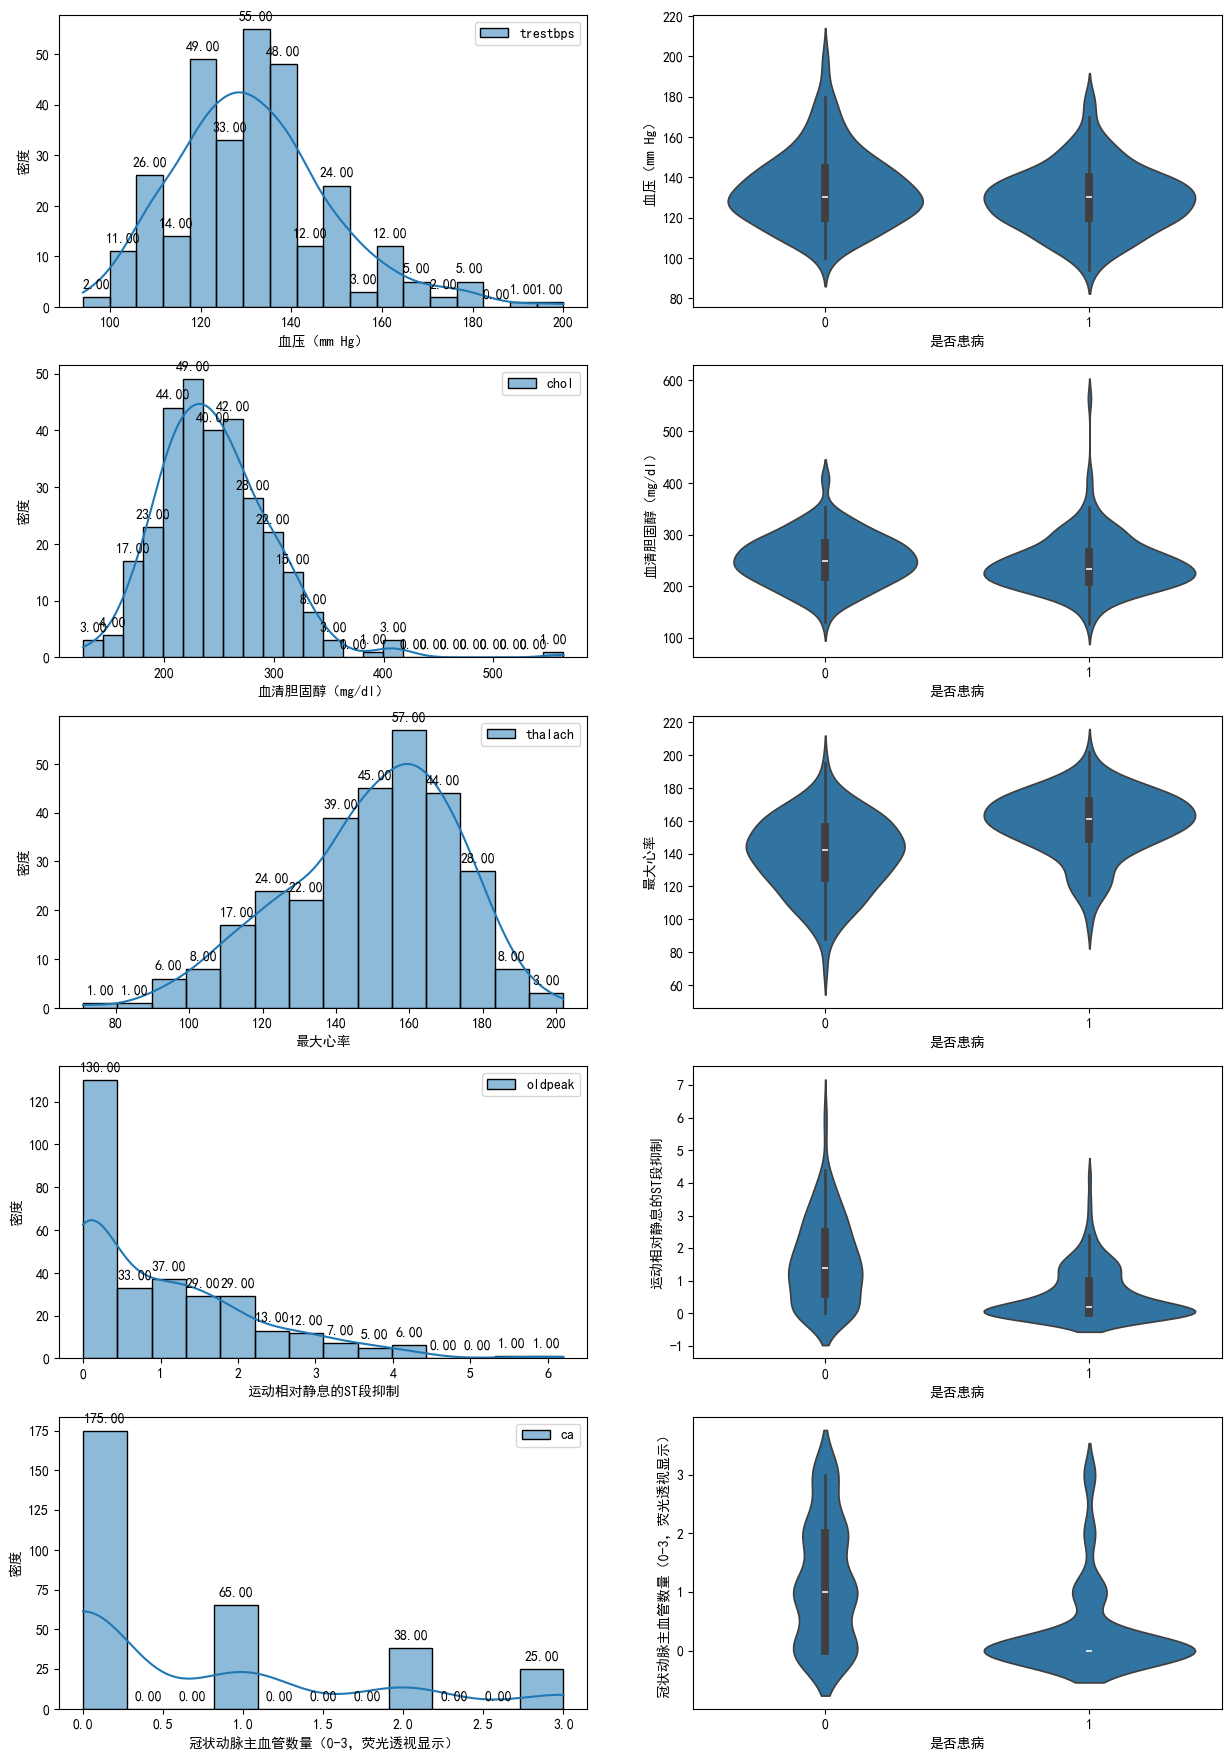

In [30]:
fig_continuous, axes = plt.subplots(nrows=len(continuous), ncols=2, figsize=(15, 22))

plotGrid(isCategorial=False)

In [31]:
#重命名数据集 data 的列名，然后显示前几行数据。
data.columns = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate_achieved',
       'exercise_induced_angina', 'st_depression', 'st_slope', 'num_major_vessels', 'thalassemia', 'target']





'''
列名说明（原始名 → 解释名）

旧列名	新列名	解释
age	age	年龄
sex	sex	性别（0 = 女性，1 = 男性）
cp	chest_pain_type	胸痛类型（0-3，共4种类型）
trestbps	resting_blood_pressure	静息血压（单位：mmHg）
chol	cholesterol	血清胆固醇（单位：mg/dL）
fbs	fasting_blood_sugar	空腹血糖是否高于120mg/dL（1 = 是，0 = 否）
restecg	rest_ecg	静息心电图结果（0-2）
thalach	max_heart_rate_achieved	最大心率
exang	exercise_induced_angina	运动诱发心绞痛（1 = 是，0 = 否）
oldpeak	st_depression	ST段下降程度（运动相对于静息状态）
slope	st_slope	ST段坡度（上升、平坦、下降）
ca	num_major_vessels	主要血管数量（0-3）
thal	thalassemia	地中海贫血（0-3，不同缺陷类型）
target	target	目标变量（1 = 患有心脏病，0 = 未患病）
'''

In [32]:
data.head(10)

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


#根据空腹血糖判断心脏病
pd.crosstab(data.fasting_blood_sugar, data.target).plot(kind="bar", figsize=(12, 6), color=['#4286f4', '#f49242'])
plt.title("根据空腹血糖判断心脏病")
plt.xlabel('空腹血糖值 (FBS > 120 mg/dl) (1 = 有病; 0 = 无病)')
plt.xticks(rotation=90)
plt.legend(["没有心脏病", "有心脏病"])
plt.ylabel('是否患病')
plt.show()



#分析胸痛（4 种胸痛类型）  [值 0：典型心绞痛，值 1：非典型心绞痛，值 2：非心绞痛，值 3：无症状]
data["chest_pain_type"].unique()

y = data["target"]
plt.figure(figsize=(12, 10))
sns.barplot(x=data["chest_pain_type"], y=y)  # 将参数传给 x 和 y
plt.title("胸痛类型的分布图")
plt.xlabel("胸痛类型")
plt.ylabel("计数或其他值")
plt.show()




#分析患者的静息血压（入院时毫米汞柱）

data["resting_blood_pressure"].unique()
     

y = data["target"]
plt.figure(figsize=(26, 10))
sns.barplot(x=data["resting_blood_pressure"], y=y)
plt.title("静息血压与心脏病的关系")
plt.xlabel("静息血压")
plt.ylabel("计数或其他值")
plt.show()


#分析静息心电图测量结果（0 = 正常，1 = ST-T 波异常，2 = 根据 Estes 标准显示可能或明确的左心室肥大）
data["rest_ecg"].unique()

import seaborn as sns
import matplotlib.pyplot as plt

# 使用 rest_ecg 类型来分组，计算 target 的均值
plt.figure(figsize=(16, 12))

# 绘制 barplot，x 为 rest_ecg 类型，y 为 target 的平均值
sns.barplot(x=data["rest_ecg"], y=data["target"], estimator="mean", errorbar=None, hue=data["rest_ecg"])

# 设置标题和标签
plt.title("静息心电图类型与心脏病结果的关系", fontsize=20, fontweight='bold', color='#2C3E50', pad=20)
plt.xlabel("静息心电图类型", fontsize=16, fontweight='bold', color='#34495E')
plt.ylabel("心脏病结果 (target)", fontsize=16, fontweight='bold', color='#34495E')

# 设置 x 轴刻度标签样式
plt.xticks(fontsize=14, rotation=45, ha='right')

# 设置 y 轴刻度标签样式
plt.yticks(fontsize=14)

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7, axis='y')

# 去除顶部和右侧的坐标轴线
sns.despine(top=True, right=True)

# 添加自定义图例
labels = ['0 = 正常', '1 = ST-T 波异常', '2 = 显示可能或明确的左心室肥大']
colors = sns.color_palette("Blues_d", 3)  # 获取用于显示类别的颜色

# 在图表右上角添加图例
plt.legend(labels=labels, loc='upper right', fontsize=14, title="静息心电图类型", title_fontsize=16, frameon=False)

# 显示图表
plt.show()



In [27]:
#   结论：restecg 为“1”和“0”的人比 restecg 为“2”的人更容易患心脏病

#分析运动诱发的心绞痛（1 = 是；0 = 否）

data["exercise_induced_angina"].unique()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
y = data["target"]
# 正确使用 hue 避免 FutureWarning
sns.barplot(x=data["exercise_induced_angina"], 
            y=data["target"], 
            estimator="mean", 
            errorbar=None, 
            hue=data["exercise_induced_angina"],  # 使用 hue
            palette="Blues_d",  
            legend=False)  # 关闭自动图例

# 设置标题和标签
plt.title("运动诱发心绞痛与心脏病的关系", fontsize=16, fontweight='bold', color='#2C3E50')
plt.xlabel("运动诱发心绞痛", fontsize=14, fontweight='bold', color='#34495E')
plt.ylabel("心脏病发生率 (target)", fontsize=14, fontweight='bold', color='#34495E')

# 设置 x 轴刻度标签
plt.xticks(ticks=[0, 1], labels=["无心绞痛", "有心绞痛"], fontsize=12)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 去除顶部和右侧的边框
sns.despine(top=True, right=True)

plt.show()



'''
1. **运动诱发心绞痛与心脏病发生率的关系**：
   - **无心绞痛（0）**的组别，心脏病的发生率较高，约为 0.7 左右。这表明大部分患有心脏病的人群，似乎并没有表现出运动诱发心绞痛。
   - **有心绞痛（1）**的组别，心脏病的发生率较低，约为 0.2 左右。说明，尽管这些人群可能有心绞痛的症状，但他们患上心脏病的概率相对较低。

2. **结论**：
   - 根据图表，可以推测运动诱发心绞痛（有心绞痛）可能与心脏病的发生率呈现某种相反的关系。那些有心绞痛的人群的心脏病发生率似乎较低。
   - 但是，这只是基于当前数据的观察结果，实际上，心脏病的发生是多因素影响的，可能还受到其他因素（如年龄、生活方式、饮食、遗传等）的影响。因此，单凭此图表我们不能做出过于绝对的结论。
运动诱发心绞痛=1 的人患心脏问题的可能性要小得多

'''

#分析峰值运动 ST 段的斜率（值 1：向上倾斜，值 2：平坦，值 3：向下倾斜）
data["st_slope"].unique()



plt.figure(figsize=(25, 10))

# 使用 hue 参数，传递 x 变量给 hue 以避免 FutureWarning
sns.barplot(x=data["st_slope"], y=data["target"], estimator="mean", errorbar=None, hue=data["st_slope"], palette="Blues_d", legend=False)

# 设置标题和标签
plt.title("ST 槽与心脏病的关系", fontsize=16, fontweight='bold', color='#2C3E50')
plt.xlabel("ST 槽 (st_slope)", fontsize=14, fontweight='bold', color='#34495E')
plt.ylabel("心脏病发生率 (target)", fontsize=14, fontweight='bold', color='#34495E')

# 设置 x 轴刻度标签
plt.xticks(fontsize=12)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 去除顶部和右侧的边框
sns.despine(top=True, right=True)

plt.show()



#结论：
#峰值运动 ST 段的斜率：斜率“2”比斜率“0”和“1”更能引起心脏疼痛

#分析荧光透视染色的主要血管数量（0-3）     《有误》





# 统计主要血管数量（0-3）的分布
plt.figure(figsize=(8, 4))
sns.countplot(x="num_major_vessels", data=data)
plt.xlabel("主要血管数量", fontsize=12)  # 设置中文标签
plt.ylabel("数量", fontsize=12)
plt.title("主要血管数量分布", fontsize=14)
plt.show()

# 绘制主要血管数量与心脏病发生概率的关系
plt.figure(figsize=(8, 4))
sns.barplot(x=data["num_major_vessels"], y=data["target"])
plt.xlabel("主要血管数量", fontsize=12)
plt.ylabel("心脏病发生概率", fontsize=12)
plt.title("主要血管数量与心脏病发生概率", fontsize=14)
plt.show()


#分析一种称为地中海贫血的血液疾病（3 = 正常；6 = 固定缺陷；7 = 可逆缺陷）

data["thalassemia"].unique()


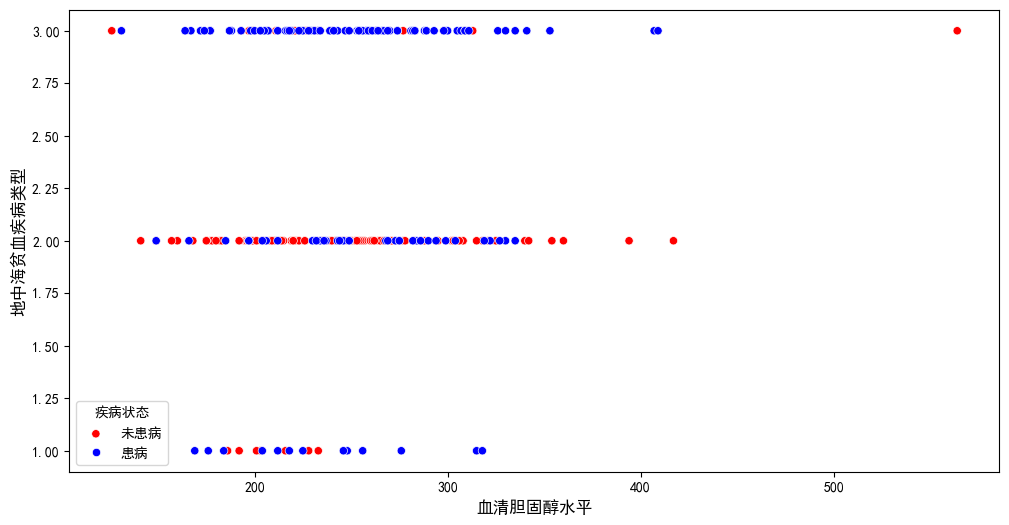

In [28]:
# 创建图形，调整大小
plt.figure(figsize=(12, 6))

# 绘制散点图，修改 target 颜色区分
sns.scatterplot(x='cholesterol', y='thalassemia', data=data, hue='target', palette={0: "blue", 1: "red"})

# 修改横轴和图例
plt.xlabel("血清胆固醇水平", fontsize=12)  
plt.ylabel("地中海贫血疾病类型", fontsize=12)  
plt.legend(title="疾病状态", labels=["未患病", "患病"])

# 显示图像
plt.show()


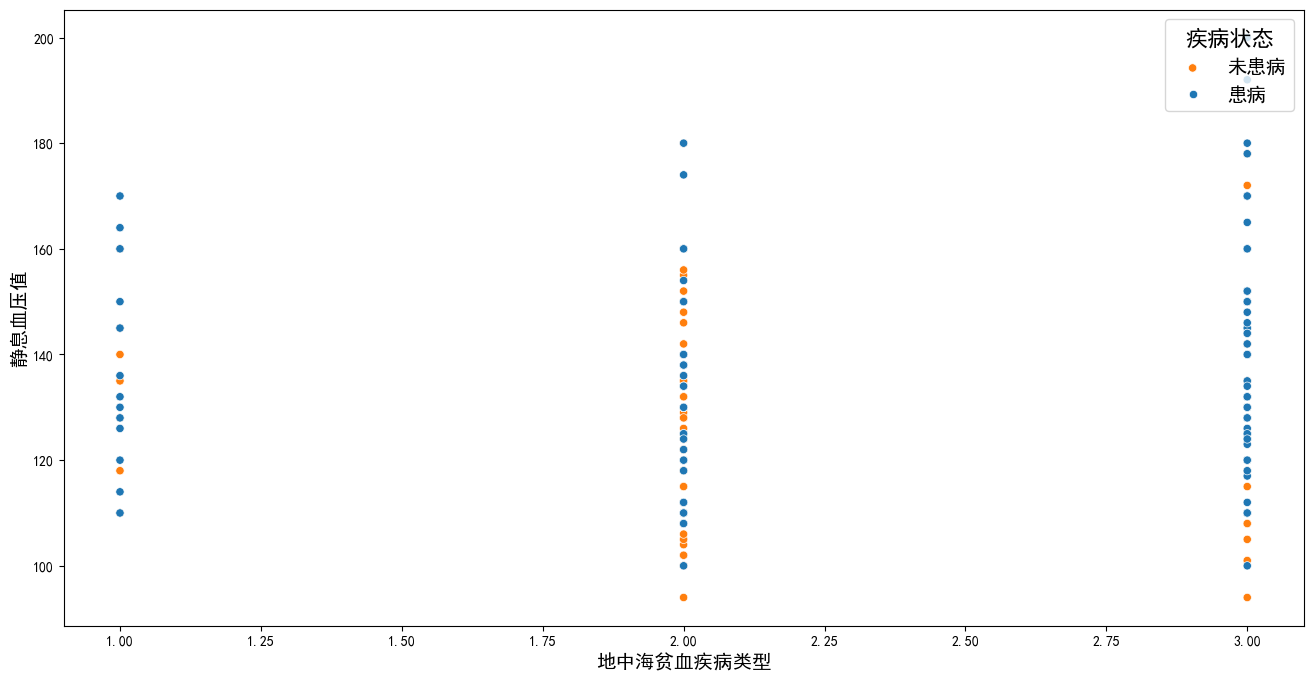

In [29]:
# 设置中文字体，假设你系统中安装了 'SimHei' 字体
font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # 根据你的系统字体路径调整

# 创建画布并设置大小
plt.figure(figsize=(16, 8))

# 绘制散点图，按 'target' 区分颜色
sns.scatterplot(x='thalassemia', y='resting_blood_pressure', data=data, hue='target')

# 设置坐标轴标签
plt.xlabel('地中海贫血疾病类型', fontproperties=font, fontsize=14)
plt.ylabel('静息血压值', fontproperties=font, fontsize=14)

# 添加图例说明，调整字体大小
plt.legend(title='疾病状态', labels=['未患病', '患病'], loc='upper right', title_fontsize=16, fontsize=14)

# 显示图表
plt.show()


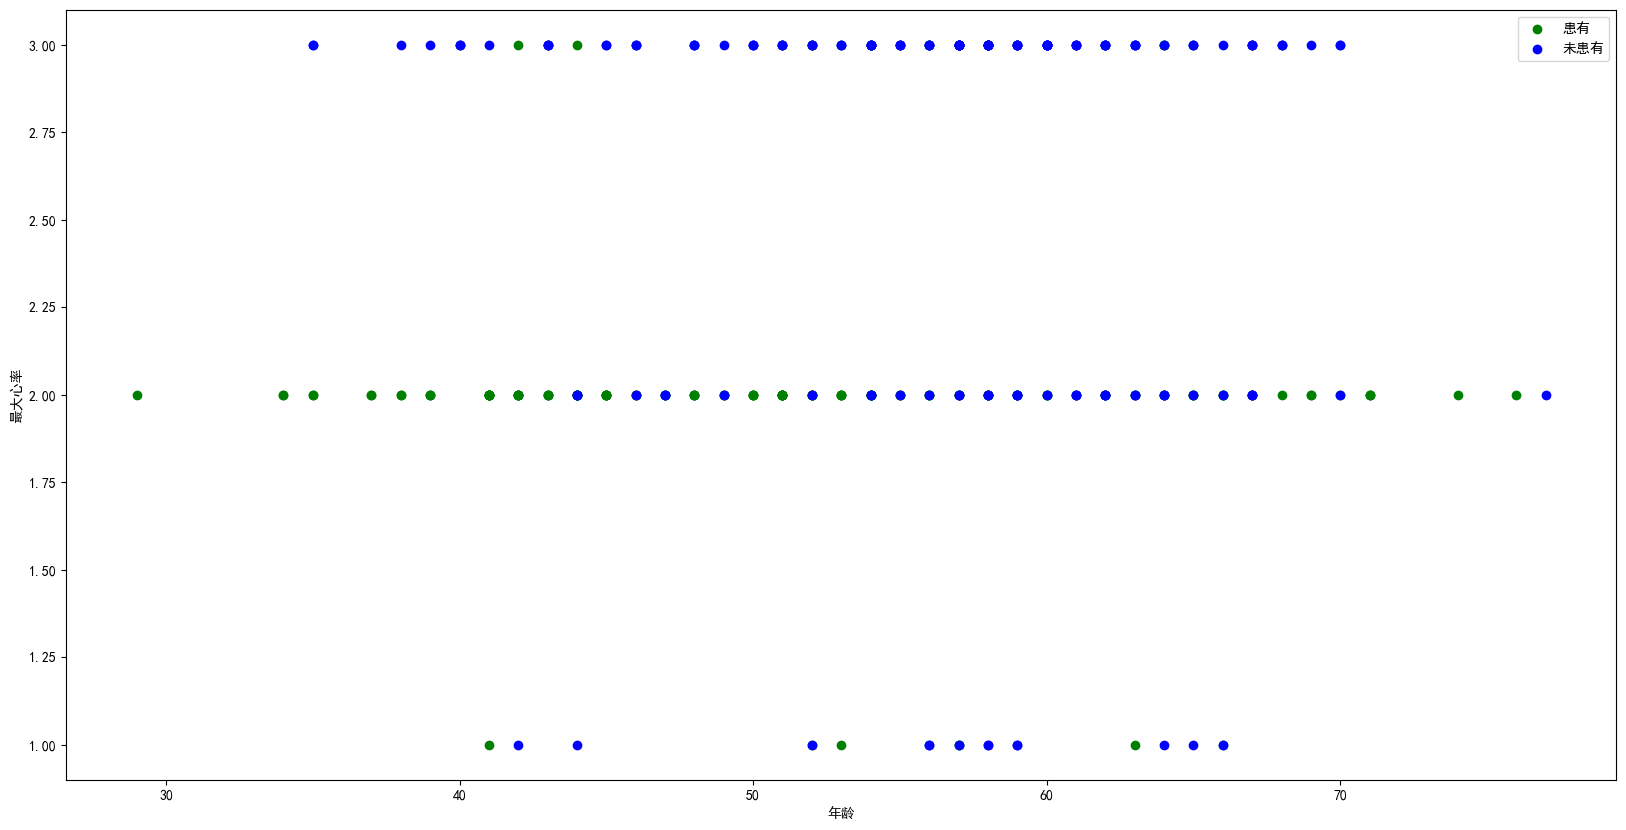

In [30]:
#   健康率与年龄
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 设置中文字体，假设你系统中安装了 'SimHei' 字体
font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # 根据你的系统字体路径调整

# 创建画布并设置大小
plt.figure(figsize=(20, 10))

# 绘制患有心脏病（target == 1）的散点图
plt.scatter(x=data.age[data.target==1], y=data.thalassemia[data.target==1], c="green", label="患有")

# 绘制未患有心脏病（target == 0）的散点图
plt.scatter(x=data.age[data.target==0], y=data.thalassemia[data.target==0], c="blue", label="未患有")

# 添加图例
plt.legend()

# 设置中文坐标轴标签
plt.xlabel("年龄", fontproperties=font)
plt.ylabel("最大心率", fontproperties=font)

# 显示图表
plt.show()



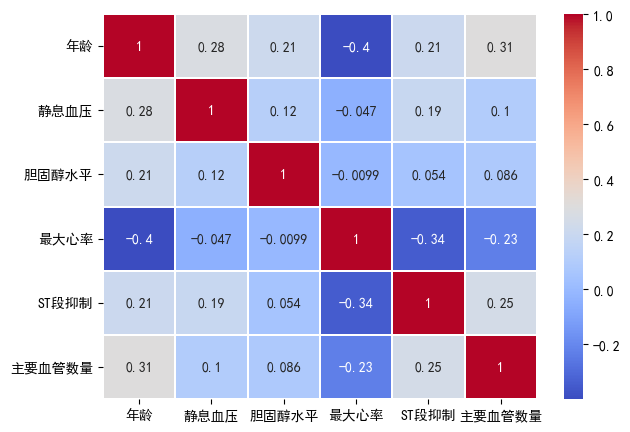

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 存储数值型变量的列名
cnames = ['age', 'resting_blood_pressure', 'cholesterol', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels']

# 设置绘图的宽度和高度
f, ax = plt.subplots(figsize=(7, 5))

# 提取数据中的数值型列
df_corr = data.loc[:, cnames]

# 生成相关系数矩阵
corr = df_corr.corr()

# 中文标签映射
columns_zh = {
    'age': '年龄',
    'resting_blood_pressure': '静息血压',
    'cholesterol': '胆固醇水平',
    'max_heart_rate_achieved': '最大心率',
    'st_depression': 'ST段抑制',
    'num_major_vessels': '主要血管数量'
}

# 重新命名数据框列名
corr.rename(index=columns_zh, columns=columns_zh, inplace=True)

# 绘制热力图，并修改颜色条图例
sns.heatmap(
    corr, annot=True, cmap='coolwarm', linewidths=.1,
   
)

# 设置颜色条的中文字体

plt.show()


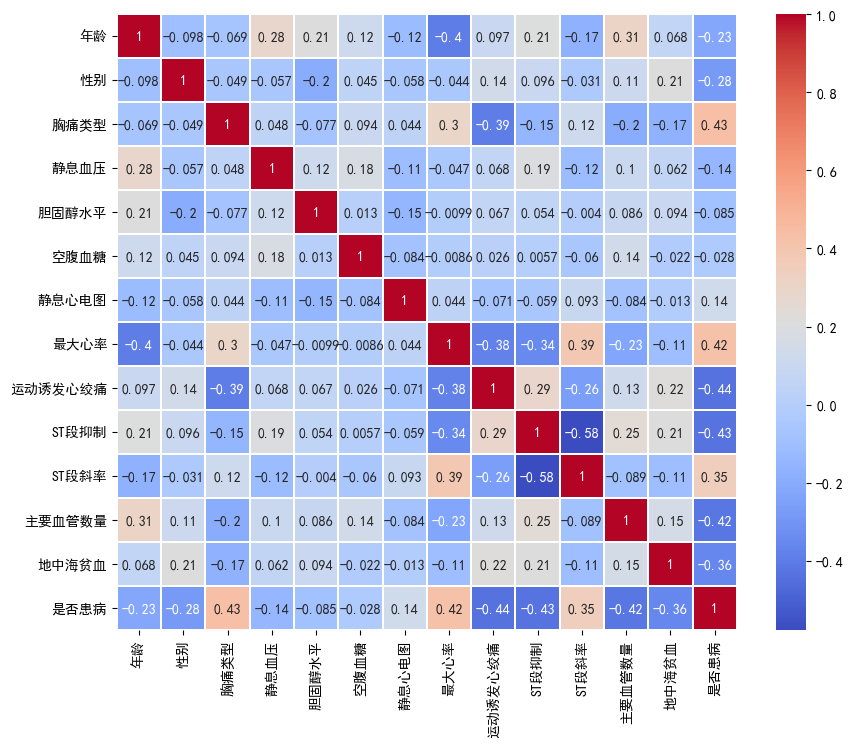

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# 重新命名数据集的列名
data.columns = [
    'age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 
    'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression', 'st_slope', 'num_major_vessels', 
    'thalassemia', 'target'
]

# 选取所有14个变量
cnames = data.columns.tolist()

# 生成相关系数矩阵
corr = data[cnames].corr()

# 创建中文标签映射
columns_zh = {
    'age': '年龄',
    'sex': '性别',
    'chest_pain_type': '胸痛类型',
    'resting_blood_pressure': '静息血压',
    'cholesterol': '胆固醇水平',
    'fasting_blood_sugar': '空腹血糖',
    'rest_ecg': '静息心电图',
    'max_heart_rate_achieved': '最大心率',
    'exercise_induced_angina': '运动诱发心绞痛',
    'st_depression': 'ST段抑制',
    'st_slope': 'ST段斜率',
    'num_major_vessels': '主要血管数量',
    'thalassemia': '地中海贫血',
    'target': '是否患病'
}

# 重新命名相关系数矩阵的行和列
corr.rename(index=columns_zh, columns=columns_zh, inplace=True)

# 设置绘图的大小
plt.figure(figsize=(10, 8))

# 绘制热力图
sns.heatmap(
    corr, annot=True, cmap='coolwarm', linewidths=0.1
)
# 保存图片，格式为 PNG，dpi 300 以保证清晰度
plt.savefig("相关性热力图.png", dpi=300, bbox_inches='tight')

# 显示图表
plt.show()


中文解释：
此代码的目的是绘制一个热力图，展示数据集中指定数值型变量之间的相关性。 
通过热力图，用户可以快速地了解哪些特征之间的关系较强，哪些关系较弱，甚至是否存在负相关或正相关。

相关性矩阵：热力图的颜色深浅代表相关性的强弱，通常颜色越深表示相关性越强，颜色越浅则表示相关性越弱。
数值显示：annot=True 参数确保每个热力图单元格中都显示具体的相关系数数值，这样可以更加直观地查看不同特征之间的关系。
结论：
通过热力图，你可以快速识别哪些变量之间有较强的相关性。 例如，如果 age 和 cholesterol 之间的相关系数为正，且值较高（接近1）
这表明年龄和胆固醇水平之间有较强的正相关关系。 '''

In [44]:
#相关性分析
'''

df_corr：这是一个新的变量，它表示从原始数据中提取的一个数据子集。该子集只包含 cnames 列表中指定的那些数值型列。
data.loc[:, cnames]：
data：表示原始数据集。
loc[]：是 Pandas 提供的用于基于标签选取数据的索引器，通常用于行列切片。
: 表示选择所有的行（即不限制行），
cnames 则指定了需要选择的列名。这些列名来自你之前定义的 cnames 列表。

整体意思：
这行代码通过 loc 从 data 数据集中选择出列名为 cnames 列表中指定的所有列，并将它们存储在新的 DataFrame 变量 df_corr 中。
df_corr 是一个新的数据框，它只包含了你在 cnames 列表中列出的那些列（即数值型变量）。这个新的数据框通常用于后续的相关性计算或其他分析。
df_corr 是从原始数据 data 中筛选出来的只包含数值型变量的子集。
''' 

df_corr = data.loc[:,cnames]
df_corr


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [33]:
#  将数据集拆分为训练和测试  （数据预处理）
'''
将数据集 data 按照 80% 和 20% 的比例划分为训练集和测试集：训练集包含 242 个样本，测试集包含 61 个样本。
分割之后，训练集和测试集的特征数据分别存储在 X_train 和 X_test 中，标签数据存储在 Y_train 和 Y_test 中。
用于训练和评估模型。
'''

from sklearn.model_selection import train_test_split

# 从数据集中分离特征和标签
predictors = data.drop("target", axis=1)  # 特征变量
target = data["target"]  # 标签变量

# 分割数据集为训练集和测试集，80% 用于训练，20% 用于测试
X_train, X_test, Y_train, Y_test = train_test_split(predictors, target, test_size=0.20, random_state=0)

# 输出训练集和测试集的记录数
print("训练集特征包含 {0} 条记录，测试集特征包含 {1} 条记录。".format(X_train.shape[0], X_test.shape[0]))

# 输出分割后的数据形状
print("训练集特征形状：", X_train.shape)
print("测试集特征形状：", X_test.shape)
print("训练集标签形状：", Y_train.shape)
print("测试集标签形状：", Y_test.shape)


训练集特征包含 242 条记录，测试集特征包含 61 条记录。
训练集特征形状： (242, 13)
测试集特征形状： (61, 13)
训练集标签形状： (242,)
测试集标签形状： (61,)



X_train, X_test, Y_train, Y_test = train_test_split(predictors, target, test_size=0.20, random_state=0)
```
- 使用 `train_test_split` 函数来将数据集 `predictors`（特征）和 `target`（标签）分割为训练集和测试集。
  - `test_size=0.20` 表示将 20% 的数据分配为测试集，剩下的 80% 用作训练集。
  - `random_state=0` 是设置随机种子，确保每次运行时都能得到相同的分割结果。

### 显示分割后的数据形状
表示训练集有 242 个样本，每个样本有 13 个特征。
表示测试集有 61 个样本，每个样本有 13 个特征。
表示训练集有 242 个标签。
表示测试集有 61 个标签。


In [34]:
#数据集被正确地分割成训练集和测试集。训练集包含 242 个样本，测试集包含 61 个样本，这符合常见的 80/20 数据分割比例。因此，数据分割没有问题。

使用机器学习进行建模和预测，主要目标是以最高的准确度预测心脏病的发生。

为了实现这一目标，我将测试五种算法。
我利用SciKit Learn 库，制定一个用于训练我们模型的通用函数。
再选择了几种典型的用于解决整个分类方法中的监督学习问题的算法。

在训练集和测试集上都显示准确度的原因是为了让我们评估模型是否过度拟合或欠拟合数据（所谓的偏差/方差权衡）。

In [35]:

#来自 sklearn.metrics 导入准确度分数
from sklearn.metrics import accuracy_score

# 定义训练和评估模型的函数
def train_model(X_train, y_train, X_test, y_test, classifier, **kwargs):
    # 实例化模型
    model = classifier(**kwargs)
    
    # 训练模型
    model.fit(X_train, y_train)
    
    # 获取训练集和测试集的准确度
    fit_accuracy = model.score(X_train, y_train)  # 训练集准确度
    test_accuracy = model.score(X_test, y_test)  # 测试集准确度
    
    # 打印准确度结果
    print(f"训练准确度：{fit_accuracy:0.2%}")
    print(f"测试准确度：{test_accuracy:0.2%}")
    
    # 返回训练好的模型
    return model



'''
代码解释：
这段代码定义了一个函数 train_model，该函数用来训练一个分类模型并评估其在训练集和测试集上的准确度。具体步骤如下：

函数参数：

X_train: 训练集特征数据。
y_train: 训练集标签数据。
X_test: 测试集特征数据。
y_test: 测试集标签数据。
classifier: 传入的分类器（例如 LogisticRegression, RandomForestClassifier 等）。
**kwargs: 其他可选的关键字参数，传递给分类器进行实例化。
实例化模型：

model = classifier(**kwargs): 通过传入的分类器创建模型实例。
训练模型：

model.fit(X_train, y_train): 使用训练集数据训练模型。
计算和打印准确度：

fit_accuracy = model.score(X_train, y_train): 计算模型在训练集上的准确度。
test_accuracy = model.score(X_test, y_test): 计算模型在测试集上的准确度。
打印结果：

使用 print(f"训练准确度：{fit_accuracy:0.2%}") 和 print(f"测试准确度：{test_accuracy:0.2%}") 打印准确度，保留两位小数。
返回模型：

return model: 返回训练好的模型，便于后续使用。
'''


逻辑回归(Logistic regression)

In [38]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


# 假设 X_train, Y_train, X_test, Y_test 已经准备好
# 1. 对数据进行标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 对训练集进行标准化
X_test_scaled = scaler.transform(X_test)  # 对测试集进行标准化

# 2. 训练 Logistic Regression 模型
logreg = LogisticRegression(random_state=0, solver='newton-cg')
logreg.fit(X_train_scaled, Y_train)

# 3. 预测结果
y_pred_lr = logreg.predict(X_test_scaled)

# 4. 计算准确度
score_lr = round(accuracy_score(Y_test, y_pred_lr) * 100, 2)
print("使用逻辑回归模型的准确率为: " + str(score_lr) + " %")

# 5. 使用 train_model 函数训练模型并输出结果
model = train_model(X_train_scaled, Y_train, X_test_scaled, Y_test, LogisticRegression, solver='newton-cg')

# 6. 计算并输出精准度（Precision），并转化为百分比
precision = precision_score(Y_test, y_pred_lr)
print("精准度（Precision）: {:.2f}%".format(precision * 100))

# 7. 计算并输出召回率（Recall），并转化为百分比
recall = recall_score(Y_test, y_pred_lr)
print("召回率（Recall）: {:.2f}%".format(recall * 100))

#8 计算并输出 F-Score（F1-Score），并转化为百分比
f_score = (2 * precision * recall) / (precision + recall)
print("F-Score (F1-得分): {:.2f}%".format(f_score * 100))

# 9. 生成混淆矩阵
cm = confusion_matrix(Y_test, y_pred_lr)
cm_df = pd.DataFrame(cm, index=['真实负类', '真实正类'], columns=['预测负类', '预测正类'])

# 打印混淆矩阵
print("\n混淆矩阵：")
print(cm_df)

# 10. 计算假阴性率（FNR）
# FNR = FN / (FN + TP)
TN, FP, FN, TP = cm.ravel()  # 将混淆矩阵展平为四个数值
fnr = FN * 100 / (FN + TP)
print(f"假阴性率（FNR）: {fnr:.2f}%")

使用逻辑回归模型的准确率为: 83.61 %
训练准确度：85.12%
测试准确度：83.61%
精准度（Precision）: 83.33%
召回率（Recall）: 88.24%
F-Score (F1-得分): 85.71%

混淆矩阵：
      预测负类  预测正类
真实负类    21     6
真实正类     4    30
假阴性率（FNR）: 11.76%


混淆矩阵

<Axes: >

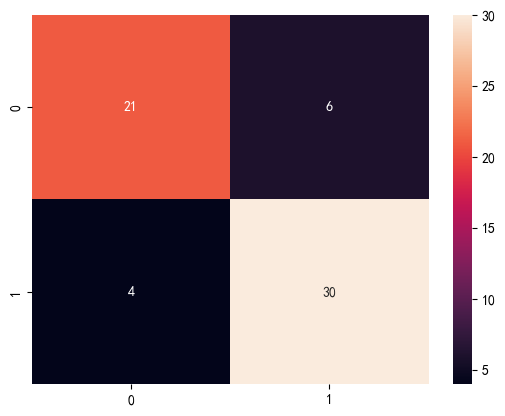

In [39]:
#生成一个混淆矩阵并通过热力图（heatmap）可视化结果
from sklearn.metrics import confusion_matrix

#计算实际标签（Y_test）和预测标签（y_pred_lr）之间的混淆矩阵。
matrix= confusion_matrix(Y_test, y_pred_lr)

#用 Seaborn 库绘制热力图，其中 annot=True 表示显示矩阵中的数值，fmt='d' 表示显示整数格式。   fmt = d 意思是格式默认
sns.heatmap(matrix,annot = True, fmt = "d")

生成一个混淆矩阵并通过热力图（heatmap）可视化结果。

从图中，可以看到一个 2x2 的矩阵。每个元素表示对应的类别预测结果：
这个矩阵表示：
21 个样本真实为 0 且预测为 0
6 个样本真实为 0 但预测为 1
4 个样本真实为 1 但预测为 0
30 个样本真实为 1 且预测为 1

这个结果表明模型的性能较好，但仍有一定的错误分类（6个0误分类为1，4个1误分类为0）。这种错误分类可能需要进一步分析和优化，例如调整模型、使用不同的特征或增加训练数据等方法来提高准确度。

如果这是心脏病预测的模型，意味着模型在预测健康（0类）和心脏病（1类）时表现出了一些误差，可能有助于医生在诊断过程中提高决策的准确性。

随机森林 (Random Forest)

使用随机森林模型的准确率: 86.89%
精准度（Precision）: 88.24%
召回率（Recall）: 88.24%
F-Score (F1得分): 88.24%

混淆矩阵：
      预测负类  预测正类
真实负类    23     4
真实正类     4    30
假阴性率（FNR）: 11.76%


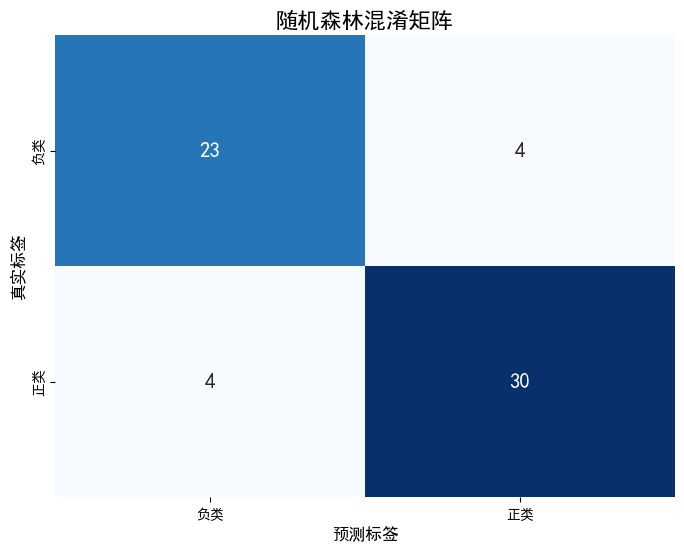

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 训练和评估模型的函数
def train_and_evaluate_model(X_train, Y_train, X_test, Y_test, model_class, **model_params):
    # 标准化数据
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 创建并训练模型
    model = model_class(**model_params)
    model.fit(X_train_scaled, Y_train)

    # 预测结果
    y_pred = model.predict(X_test_scaled)

    # 计算各类指标
    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    f_score = f1_score(Y_test, y_pred)
    cm = confusion_matrix(Y_test, y_pred)

    # 返回评估结果
    return accuracy, precision, recall, f_score, cm

# 绘制混淆矩阵的函数
def plot_confusion_matrix(cm):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["负类", "正类"], yticklabels=["负类", "正类"], 
                cbar=False, annot_kws={"size": 15})
    plt.title("随机森林混淆矩阵", fontsize=16)
    plt.xlabel("预测标签", fontsize=12)
    plt.ylabel("真实标签", fontsize=12)
    plt.show()

# 计算假阴性率的函数
def calculate_fnr(cm):
    TN, FP, FN, TP = cm.ravel()  # 将混淆矩阵展平为四个数值
    fnr = FN * 100 / (FN + TP)
    return fnr

# 使用 RandomForestClassifier 训练并评估模型
accuracy, precision, recall, f_score, cm = train_and_evaluate_model(
    X_train, Y_train, X_test, Y_test, RandomForestClassifier, n_estimators=100, random_state=0
)

# 输出各类指标
print(f"使用随机森林模型的准确率: {accuracy * 100:.2f}%")
print(f"精准度（Precision）: {precision * 100:.2f}%")
print(f"召回率（Recall）: {recall * 100:.2f}%")
print(f"F-Score (F1得分): {f_score * 100:.2f}%")

# 打印混淆矩阵
cm_df = pd.DataFrame(cm, index=['真实负类', '真实正类'], columns=['预测负类', '预测正类'])
print("\n混淆矩阵：")
print(cm_df)

# 计算并输出假阴性率
fnr = calculate_fnr(cm)
print(f"假阴性率（FNR）: {fnr:.2f}%")

# 绘制混淆矩阵
plot_confusion_matrix(cm)


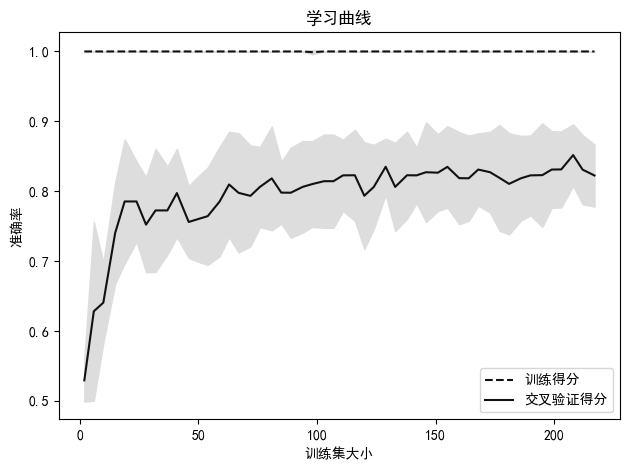

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier

# 创建CV训练和测试分数，针对不同训练集大小
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(), 
    X_train, 
    Y_train,
    cv=10,  # 交叉验证折数
    scoring='accuracy',  # 评估指标
    n_jobs=-1,  # 使用所有计算机核心
    train_sizes=np.linspace(0.01, 1.0, 50)  # 使用50个不同大小的训练集
)

# 计算训练集分数的均值和标准差
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# 计算测试集分数的均值和标准差
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 绘制学习曲线
plt.plot(train_sizes, train_mean, '--', color="#111111", label="训练得分")
plt.plot(train_sizes, test_mean, color="#111111", label="交叉验证得分")

# 绘制阴影带（标准差带）
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="#DDDDDD")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="#DDDDDD")

# 设置图表标题和标签
plt.title("学习曲线")
plt.xlabel("训练集大小"), plt.ylabel("准确率")
plt.legend(loc="best")

# 使用支持中文的字体（如果没有安装该字体，可以选择适当的字体）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体以支持中文
plt.tight_layout()  # 自动调整子图参数，以防止标签被遮挡
plt.show()


可以得出以下结论：

1. 训练得分和交叉验证得分的变化趋势：
训练得分（虚线）随着训练集大小的增加呈现上升趋势，并且在训练集较小时，得分变化较大，显示出模型在小训练集上可能存在过拟合现象。
交叉验证得分（实线）随着训练集大小增加而趋于平稳，这表明模型在不同的数据集上表现更加一致。
2. 过拟合/欠拟合：
过拟合现象： 在训练集较小的区域，训练得分远高于交叉验证得分，可能表明模型过拟合了训练集数据，即模型在训练集上表现很好，但在未见过的测试集上泛化能力较差。
收敛： 随着训练集的增加，训练得分和交叉验证得分逐渐接近，并且都趋于稳定，表明模型的泛化能力逐渐增强，训练数据量的增加有助于减轻过拟合现象。
3. 准确率的最终表现：
当训练集大小达到一定程度时，交叉验证得分和训练得分都趋于平稳，并且最终准确率都接近1.0，表明随着更多的数据投入，模型达到了较好的性能和泛化能力。
4. 模型的稳定性：
标准差阴影区域显示了模型性能的波动范围，可以看出在训练集较小的时候，模型的标准差较大，这表明模型在小训练集上较为不稳定。
总结：
随着训练集大小的增加，模型的准确性逐渐提升，且训练集和交叉验证集的得分差距逐步减小，表现出模型逐步从过拟合走向更好的泛化能力。
对于较小的训练集，可能需要增加数据量来改进模型的稳定性和准确性。




现在，让我们修剪树的深度并检查准确性。

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# 使用网格搜索进行超参数调优
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rf1 = RandomForestClassifier(random_state=0)
grid_search = GridSearchCV(rf1, param_grid, cv=5, n_jobs=-1, verbose=2)

# 训练模型
grid_search.fit(X_train, Y_train)

# 输出最佳参数和测试集准确率
print("找到的最佳参数: ", grid_search.best_params_)
best_rf = grid_search.best_estimator_
print("测试集上的准确率: {:.3f}".format(best_rf.score(X_test, Y_test)))



Fitting 5 folds for each of 27 candidates, totalling 135 fits
找到的最佳参数:  {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
测试集上的准确率: 0.869


网格参数优化评估结果：
准确率: 86.89%
精确度: 88.24%
召回率: 88.24%
F1得分: 88.24%
混淆矩阵:
      预测负类  预测正类
真实负类    23     4
真实正类     4    30
初始假阴性率 (FNR): 11.76%

优化阈值后的评估结果：
准确率: 83.61%
精确度: 80.00%
召回率: 94.12%
F1得分: 86.49%
混淆矩阵:
      预测负类  预测正类
真实负类    19     8
真实正类     2    32
优化后假阴性率 (FNR): 5.88%


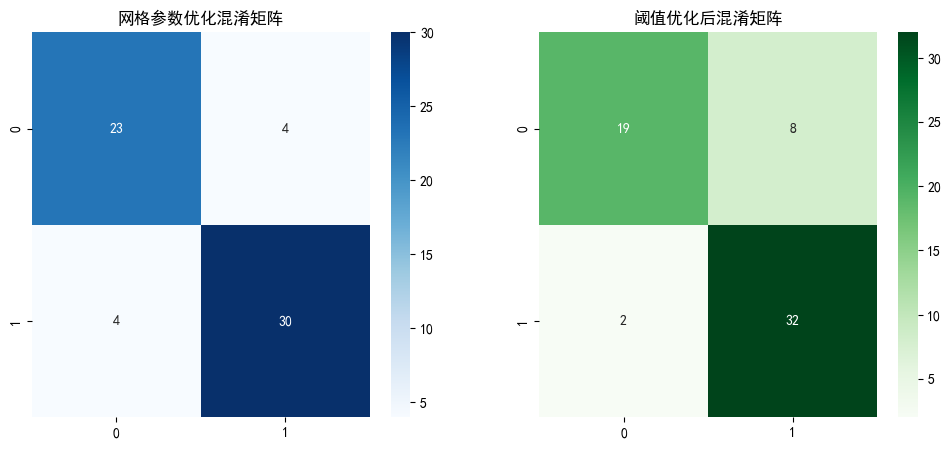

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 计算假阴性率 (FNR)
def calculate_fnr(cm):
    TN, FP, FN, TP = cm.ravel()  # 混淆矩阵的四个值，分别是 True Negatives, False Positives, False Negatives, True Positives
    fnr = FN / (FN + TP)  # 计算假阴性率
    return fnr

# 1. 训练初始模型并评估

# 使用网格搜索得到的最佳参数
best_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 10,
    'random_state': 0
}

# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 初始化随机森林模型
rf_model = RandomForestClassifier(**best_params)
rf_model.fit(X_train_scaled, Y_train)

# 预测并评估
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]  # 获取为正类的预测概率

# 计算指标
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)

# 输出初始模型评估结果
print("网格参数优化评估结果：")
print(f"准确率: {accuracy * 100:.2f}%")
print(f"精确度: {precision * 100:.2f}%")
print(f"召回率: {recall * 100:.2f}%")
print(f"F1得分: {f1 * 100:.2f}%")
print("混淆矩阵:")
print(pd.DataFrame(cm, 
                   index=['真实负类', '真实正类'], 
                   columns=['预测负类', '预测正类']))
print(f"初始假阴性率 (FNR): {calculate_fnr(cm) * 100:.2f}%\n")

# ------------------ 2. 调整阈值优化假阴性率 ------------------

# 寻找最佳阈值（手动设置为0.3，也可使用ROC曲线等方式）
threshold = 0.3  # 设置较低的阈值，以增加预测正类的概率

# 应用新阈值
y_pred_adj = (y_proba >= threshold).astype(int)

# 重新计算指标
adj_accuracy = accuracy_score(Y_test, y_pred_adj)
adj_precision = precision_score(Y_test, y_pred_adj)
adj_recall = recall_score(Y_test, y_pred_adj)
adj_f1 = f1_score(Y_test, y_pred_adj)
adj_cm = confusion_matrix(Y_test, y_pred_adj)

# 输出优化后模型评估结果
print("优化阈值后的评估结果：")
print(f"准确率: {adj_accuracy * 100:.2f}%")
print(f"精确度: {adj_precision * 100:.2f}%")
print(f"召回率: {adj_recall * 100:.2f}%")
print(f"F1得分: {adj_f1 * 100:.2f}%")
print("混淆矩阵:")
print(pd.DataFrame(adj_cm, 
                   index=['真实负类', '真实正类'], 
                   columns=['预测负类', '预测正类']))
print(f"优化后假阴性率 (FNR): {calculate_fnr(adj_cm) * 100:.2f}%")

# ------------------ 3. 绘制混淆矩阵对比图 ------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["0", "1"], yticklabels=["0", "1"])
axes[0].set_title("网格参数优化混淆矩阵")
sns.heatmap(adj_cm, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["0", "1"], yticklabels=["0", "1"])
axes[1].set_title("阈值优化后混淆矩阵")
plt.show()







朴素贝叶斯 （Naive Bayes）算法


In [44]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 训练模型的函数
def train_model(X_train, Y_train, X_test, Y_test, model_class):
    # 实例化模型
    model = model_class()
    # 训练模型
    model.fit(X_train, Y_train)
    
    # 预测训练集和测试集
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # 计算训练集和测试集准确率
    train_accuracy = accuracy_score(Y_train, y_pred_train) * 100
    test_accuracy = accuracy_score(Y_test, y_pred_test) * 100
    
    return model, train_accuracy, test_accuracy, y_pred_test

# 使用Gaussian Naive Bayes训练模型
model, train_accuracy, test_accuracy, y_pred_nb = train_model(X_train, Y_train, X_test, Y_test, GaussianNB)

# 输出训练和测试准确率
print(f"训练准确率: {train_accuracy:.2f}%")
print(f"测试准确率: {test_accuracy:.2f}%")

# 输出预测结果
print(f"预测: {y_pred_nb}")

# 计算并输出最终的测试准确率
score_nb = round(test_accuracy, 2)
print(f"使用朴素贝叶斯实现的准确率得分是: {score_nb} %")


训练准确率: 84.71%
测试准确率: 85.25%
预测: [0 1 1 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 0 0 1 0 0 1 1 1 0 0 1 1 1 0 0
 1 0 0 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1]
使用朴素贝叶斯实现的准确率得分是: 85.25 %


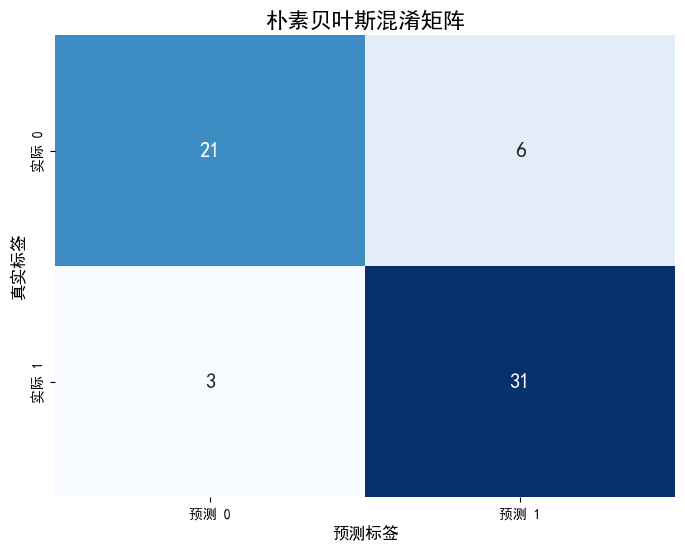

精度（Precision）: 0.8378
召回率（Recall）: 0.9118
F1分数: 0.8732
假阴性率（FNR）: 8.82%


In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# 预测结果
y_pred_nb = model.predict(X_test)

# 计算混淆矩阵
matrix = confusion_matrix(Y_test, y_pred_nb)

# 将混淆矩阵转为 DataFrame，并设置行列标签
CM = pd.DataFrame(matrix, columns=["预测 0", "预测 1"], index=["实际 0", "实际 1"])

# 绘制热图
plt.figure(figsize=(8, 6))
sns.heatmap(CM, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 15})
plt.title("朴素贝叶斯混淆矩阵", fontsize=16)
plt.xlabel("预测标签", fontsize=12)
plt.ylabel("真实标签", fontsize=12)
plt.show()

# 精度（Precision）
precision = precision_score(Y_test, y_pred_nb)
print(f"精度（Precision）: {precision:.4f}")

# 召回率（Recall）
recall = recall_score(Y_test, y_pred_nb)
print(f"召回率（Recall）: {recall:.4f}")

# F1分数
f1_score = (2 * precision * recall) / (precision + recall)
print(f"F1分数: {f1_score:.4f}")

# 从混淆矩阵中提取值
TN = CM.iloc[0, 0]  # True Negative
FP = CM.iloc[0, 1]  # False Positive
FN = CM.iloc[1, 0]  # False Negative
TP = CM.iloc[1, 1]  # True Positive

# 假阴性率（False Negative Rate, FNR）
fnr = FN * 100 / (FN + TP)
print(f"假阴性率（FNR）: {fnr:.2f}%")


In [47]:




from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 训练模型的函数
def train_model(X_train, Y_train, X_test, Y_test, model_class, **kwargs):
    # 实例化模型
    model = model_class(**kwargs)
    
    # 训练模型
    model.fit(X_train, Y_train)
    
    # 预测训练集和测试集
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # 计算训练集和测试集准确率
    train_accuracy = accuracy_score(Y_train, y_pred_train) * 100
    test_accuracy = accuracy_score(Y_test, y_pred_test) * 100
    
    return model, train_accuracy, test_accuracy, y_pred_test

# 初始 KNN 模型训练
knn, train_accuracy, test_accuracy, y_pred_knn = train_model(X_train, Y_train, X_test, Y_test, KNeighborsClassifier, n_neighbors=8)

# 输出初始 KNN 模型的准确率
print(f"训练集准确率: {train_accuracy:.2f}%")
print(f"测试集准确率: {test_accuracy:.2f}%")
print(f"预测结果: {y_pred_knn}")

# 输出最终的测试准确率
print(f"使用 KNN 模型得到的准确率是: {test_accuracy:.2f}%")

# 寻找最佳的 n_neighbors 参数
best_n_neighbors = 1
best_test_accuracy = 0
print("\n尝试不同的 n_neighbors 参数以寻找最佳值:\n")

for i in range(1, 10):
    print(f"尝试 n_neighbors = {i}...")
    _, _, test_acc, _ = train_model(X_train, Y_train, X_test, Y_test, KNeighborsClassifier, n_neighbors=i)
    print(f"n_neighbors = {i} 的测试集准确率: {test_acc:.2f}%")
    
    # 找到最佳的 n_neighbors
    if test_acc > best_test_accuracy:
        best_n_neighbors = i
        best_test_accuracy = test_acc

# 输出最佳 n_neighbors 和对应的测试准确率
print(f"\n最佳 n_neighbors 值为: {best_n_neighbors}，对应的测试集准确率为: {best_test_accuracy:.2f}%")


训练集准确率: 71.90%
测试集准确率: 67.21%
预测结果: [0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0
 1 0 1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 0]
使用 KNN 模型得到的准确率是: 67.21%

尝试不同的 n_neighbors 参数以寻找最佳值:

尝试 n_neighbors = 1...
n_neighbors = 1 的测试集准确率: 52.46%
尝试 n_neighbors = 2...
n_neighbors = 2 的测试集准确率: 60.66%
尝试 n_neighbors = 3...
n_neighbors = 3 的测试集准确率: 63.93%
尝试 n_neighbors = 4...
n_neighbors = 4 的测试集准确率: 63.93%
尝试 n_neighbors = 5...
n_neighbors = 5 的测试集准确率: 63.93%
尝试 n_neighbors = 6...
n_neighbors = 6 的测试集准确率: 65.57%
尝试 n_neighbors = 7...
n_neighbors = 7 的测试集准确率: 67.21%
尝试 n_neighbors = 8...
n_neighbors = 8 的测试集准确率: 67.21%
尝试 n_neighbors = 9...
n_neighbors = 9 的测试集准确率: 67.21%

最佳 n_neighbors 值为: 7，对应的测试集准确率为: 67.21%


train_model 函数                 
解释：
这是一个封装了模型训练和评估的通用函数，接受训练集（X_train, Y_train）、测试集（X_test, Y_test）、模型类别（model_class）以及模型的超参数（**kwargs）。
model_class(**kwargs)：实例化传入的模型类，并将超参数传递给模型（例如，n_neighbors=8 传给 KNN 模型）。
model.fit(X_train, Y_train)：训练模型，使用训练数据 X_train 和对应的标签 Y_train。
model.predict(X_train) 和 model.predict(X_test)：对训练集和测试集分别进行预测。
accuracy_score(Y_train, y_pred_train) 和 accuracy_score(Y_test, y_pred_test)：计算训练集和测试集的准确率。
函数返回模型本身、训练准确率、测试准确率和测试集的预测结果。


KNN 模型训练和测试
解释：
这一行调用了 train_model 函数，传入训练集和测试集数据，使用 KNeighborsClassifier 作为模型类，
设置超参数 n_neighbors=8，并返回训练好的模型以及对应的训练和测试准确率。
train_accuracy 和 test_accuracy 分别存储训练集和测试集的准确率，y_pred_knn 存储 KNN 在测试集上的预测结果。


3. 输出初始 KNN 模型的准确率
解释：

使用 f-string 格式化输出训练集和测试集的准确率，并且格式化保留两位小数。
输出模型在测试集上的预测结果 y_pred_knn，以便查看预测的类别。

4. 寻找最佳的 n_neighbors 超参数
解释：

for i in range(1, 10)：循环从 1 到 9，尝试不同的 n_neighbors 超参数。
train_model(X_train, Y_train, X_test, Y_test, KNeighborsClassifier, n_neighbors=i)：每次尝试不同的 n_neighbors 值，训练模型并返回测试集准确率。
输出每次尝试的准确率 test_acc，并通过 if test_acc > best_test_accuracy 判断当前准确率是否优于之前的最佳准确率。如果优于，则更新最佳 n_neighbors 值和 best_test_accuracy。
通过这种方式，我们可以找到测试集准确率最高的 n_neighbors 值。


5. 输出最佳的 n_neighbors 值和对应的测试集准确率
在超参数搜索完成后，输出最终选择的最佳 n_neighbors 值，并且显示该值对应的测试集准确率。


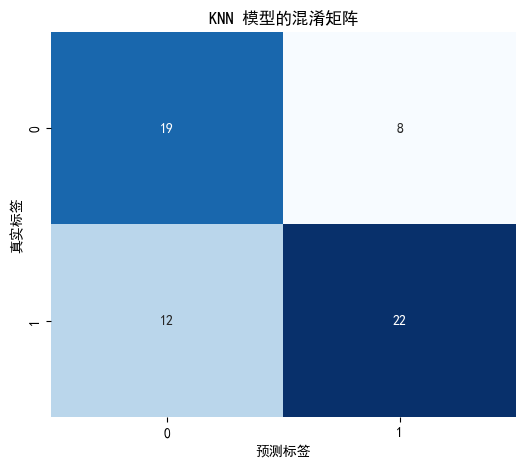

精确率 (Precision): 73.33%
召回率 (Recall): 64.71%
F1 分数 (F-Score): 68.75%
混淆矩阵 (Confusion Matrix):
 col_0    0   1
target        
0       19   8
1       12  22
假负率 (False Negative Rate, FNR): 35.29%


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
import pandas as pd

# 计算并输出混淆矩阵
matrix = confusion_matrix(Y_test, y_pred_knn)

# 绘制热图
plt.figure(figsize=(6, 5))  # 调整热图大小
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("KNN 模型的混淆矩阵")
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.show()

# 计算精确率 (Precision)
precision = precision_score(Y_test, y_pred_knn)
print(f"精确率 (Precision): {precision * 100:.2f}%")

# 计算召回率 (Recall)
recall = recall_score(Y_test, y_pred_knn)
print(f"召回率 (Recall): {recall * 100:.2f}%")

# 计算 F1 分数 (F-Score)
f1_score = (2 * precision * recall) / (precision + recall)
print(f"F1 分数 (F-Score): {f1_score * 100:.2f}%")

# 使用交叉表输出混淆矩阵
CM = pd.crosstab(Y_test, y_pred_knn)
print("混淆矩阵 (Confusion Matrix):\n", CM)

# 计算混淆矩阵的各个值
TN = CM.iloc[0, 0]  # 真负
FP = CM.iloc[0, 1]  # 假正
FN = CM.iloc[1, 0]  # 假负
TP = CM.iloc[1, 1]  # 真正

# 计算假负率 (False Negative Rate, FNR)
fnr = FN * 100 / (FN + TP)
print(f"假负率 (False Negative Rate, FNR): {fnr:.2f}%")



解释：
1.绘制混淆矩阵热图：
confusion_matrix(Y_test, y_pred_knn) 计算真实标签 Y_test 和预测标签 y_pred_knn 之间的混淆矩阵。
sns.heatmap 用于可视化混淆矩阵。
annot=True 表示在每个单元格内显示数值，fmt="d" 表示数值以整数形式显示，cmap="Blues" 设置热图颜色，cbar=False 去掉颜色条。
plt.figure(figsize=(6, 5)) 调整图像大小，使其更易查看。

2.计算精确率 (Precision)：
精确率是正确预测为正类的样本占所有被预测为正类样本的比例。
precision_score 计算精确率，{precision:.2f} 格式化输出保留两位小数。

计算召回率 (Recall)：召回率是正确预测为正类的样本占所有真实正类样本的比例
recall_score 计算召回率，{recall:.2f} 格式化输出保留两位小数。

计算 F1 分数 (F-Score)：
F1 分数是精确率和召回率的调和平均数，公式为：
F1 分数兼顾了精确率和召回率，特别在数据不均衡时很有用。


输出混淆矩阵的交叉表 (Cross Tabulation)：
pd.crosstab 生成一个交叉表，显示真实标签与预测标签之间的对应关系，结果为混淆矩阵。


计算假负率 (False Negative Rate, FNR)：
假负率是被预测为负类的实际正类样本占所有实际正类样本的比例。
FN 是假负的样本数，TP 是真正的样本数，fnr 计算并以百分比形式输出。



In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 训练决策树模型，限制树的最大深度为3，防止过拟合
tree1 = DecisionTreeClassifier(max_depth=3, random_state=0)

# 训练模型
tree1.fit(X_train, Y_train)

# 对训练集和测试集进行预测，并计算准确率
train_accuracy = tree1.score(X_train, Y_train)
test_accuracy = tree1.score(X_test, Y_test)

# 输出训练集和测试集的准确率（百分比形式）
print(f"训练集准确率: {train_accuracy * 100:.2f}%")
print(f"测试集准确率: {test_accuracy * 100:.2f}%")

# 通过决策树模型对测试集进行预测
y_pred_dt = tree1.predict(X_test)

# 计算决策树模型的预测准确率
score_dt = accuracy_score(y_pred_dt, Y_test) * 100

# 输出决策树的准确率（百分比形式）
print(f"使用决策树模型在测试集上的准确率为: {score_dt:.2f}%")



训练集准确率: 84.30%
测试集准确率: 81.97%
使用决策树模型在测试集上的准确率为: 81.97%


解释：
决策树模型的训练与预测：

使用 DecisionTreeClassifier(max_depth=3, random_state=0) 创建决策树模型，并将 max_depth=3 设置为最大深度，以减少过拟合。
使用 tree1.fit(X_train, Y_train) 训练模型。
然后使用 tree1.score(X_train, Y_train) 和 tree1.score(X_test, Y_test) 计算训练集和测试集的准确率。
输出训练集和测试集的准确率：

输出的结果表明，训练集的准确率为 1.000，说明模型完美拟合了训练数据；而测试集准确率较低，为 0.787，这表明模型存在过拟合问题，无法很好地泛化到新数据上。
通过控制树的深度来减少过拟合：

max_depth=3 限制了树的最大深度，从而降低了过拟合现象。
设置深度为 3 后，模型的训练集准确率降至 0.843，测试集准确率提高到 0.820，说明模型的泛化能力有所提高。
准确率的计算：

使用 tree1.predict(X_test) 对测试集进行预测，并计算预测的准确率。使用 accuracy_score(y_pred_dt, Y_test) 得到最终的测试集准确率。
优化后的输出：

使用 f-string 格式化输出，确保结果保留三位小数，输出更加清晰易懂。

In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 10],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=5)
grid_search.fit(X_train, Y_train)

# 输出最佳参数
print("Best parameters found: ", grid_search.best_params_)


Best parameters found:  {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [52]:
# 1. 使用网格搜索得到的最佳参数创建决策树模型
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

best_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, min_samples_split=2, random_state=0)

# 2. 在训练集上训练模型
best_tree.fit(X_train, Y_train)

# 3. 在训练集和测试集上进行预测
train_pred = best_tree.predict(X_train)
test_pred = best_tree.predict(X_test)

# 4. 计算准确率
train_accuracy = accuracy_score(Y_train, train_pred)
test_accuracy = accuracy_score(Y_test, test_pred)

# 5. 输出准确率
print(f"训练集准确率: {train_accuracy * 100:.2f}%")
print(f"测试集准确率: {test_accuracy * 100:.2f}%")


训练集准确率: 85.54%
测试集准确率: 80.33%


<Axes: >

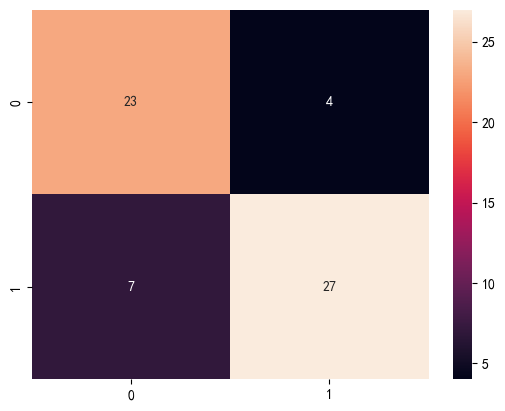

In [53]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
     

matrix= confusion_matrix(Y_test, y_pred_dt)
     

sns.heatmap(matrix,annot = True, fmt = "d")
     

In [54]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# 计算精确率 (Precision)
precision = precision_score(Y_test, y_pred_dt)
print(f"精确率 (Precision): {precision * 100:.2f}%")

# 计算召回率 (Recall)
recall = recall_score(Y_test, y_pred_dt)
print(f"召回率 (Recall): {recall * 100:.2f}%")

# 计算 F1 分数 (F-Score)
f1_score = (2 * precision * recall) / (precision + recall)
print(f"F1 分数 (F-Score): {f1_score * 100:.2f}%")

# 计算混淆矩阵 (Confusion Matrix)
CM = pd.crosstab(Y_test, y_pred_dt, rownames=['真实标签'], colnames=['预测标签'])
print("混淆矩阵 (Confusion Matrix):\n", CM)

# 计算假负率 (False Negative Rate, FNR)
TN = CM.iloc[0, 0]  # 真负
FP = CM.iloc[0, 1]  # 假正
FN = CM.iloc[1, 0]  # 假负
TP = CM.iloc[1, 1]  # 真正

# 假负率公式：FNR = 假负 / (假负 + 真正)
fnr = FN * 100 / (FN + TP)
print(f"假负率 (False Negative Rate, FNR): {fnr:.2f}%")



精确率 (Precision): 87.10%
召回率 (Recall): 79.41%
F1 分数 (F-Score): 83.08%
混淆矩阵 (Confusion Matrix):
 预测标签   0   1
真实标签        
0     23   4
1      7  27
假负率 (False Negative Rate, FNR): 20.59%


模型性能对比:
       Accuracy  Precision  Recall     F1  FNR (%)
Model                                             
KNN       0.773      0.860   0.671  0.754   32.903
决策树       0.840      0.891   0.787  0.836   21.290
逻辑回归      0.850      0.877   0.826  0.850   17.419
朴素贝叶斯     0.813      0.878   0.742  0.804   25.806
随机森林      0.860      0.884   0.839  0.861   16.129

KNN 混淆矩阵:
      预测负类  预测正类
真实负类   128    17
真实正类    51   104

决策树 混淆矩阵:
      预测负类  预测正类
真实负类   130    15
真实正类    33   122

逻辑回归 混淆矩阵:
      预测负类  预测正类
真实负类   127    18
真实正类    27   128

朴素贝叶斯 混淆矩阵:
      预测负类  预测正类
真实负类   129    16
真实正类    40   115

随机森林 混淆矩阵:
      预测负类  预测正类
真实负类   128    17
真实正类    25   130


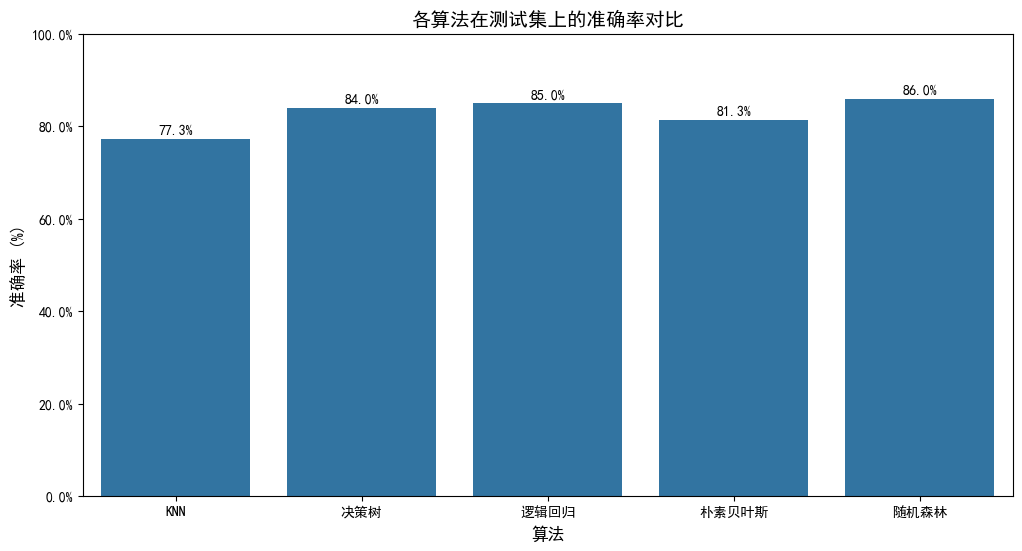

In [58]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 生成数据
X, Y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 定义模型列表
classifiers = ['KNN', '决策树', '逻辑回归', '朴素贝叶斯', '随机森林']
models = [
    KNeighborsClassifier(n_neighbors=8),
    DecisionTreeClassifier(max_depth=3, random_state=0),
    LogisticRegression(max_iter=1000),
    GaussianNB(),
    RandomForestClassifier(n_estimators=100, random_state=0)
]

# 存储所有评估结果的 DataFrame
results = []

# 评估模型
def evaluate_model(name, model):
    model.fit(X_train_scaled, Y_train)
    y_pred = model.predict(X_test_scaled)
    
    # 计算评估指标
    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    
    # 混淆矩阵和假负率（FNR）
    cm = confusion_matrix(Y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) * 100
    
    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'FNR (%)': fnr,
        'Confusion Matrix': cm
    }

# 训练并评估所有模型
for name, model in zip(classifiers, models):
    results.append(evaluate_model(name, model))

# 转换为 DataFrame
results_df = pd.DataFrame(results).set_index('Model')

# 输出模型性能对比
print("模型性能对比:")
print(results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'FNR (%)']].round(3))

# 打印混淆矩阵
for result in results:
    print(f"\n{result['Model']} 混淆矩阵:")
    print(pd.DataFrame(result['Confusion Matrix'], 
                      index=['真实负类', '真实正类'], 
                      columns=['预测负类', '预测正类']))

# 可视化准确率对比
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=classifiers, y=results_df['Accuracy'] * 100)
plt.title('各算法在测试集上的准确率对比', fontsize=14)
plt.xlabel('算法', fontsize=12)
plt.ylabel('准确率 (%)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
plt.ylim(0, 100)

# 添加数值标签
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center',
        fontsize=10
    )

# 显示图表
plt.show()